# Imports

In [1]:
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 29.9 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (
    precision_recall_curve, precision_score, recall_score, f1_score,
    confusion_matrix, balanced_accuracy_score, roc_auc_score, average_precision_score
)

In [3]:
data = pd.read_csv('monthly_master (1).csv')

In [4]:
data.head()

,store_id,period_month,tpn,gmv,days_with_orders,markdown_mean,avg_shipping_cost,si_ios_prop,si_meli_prop,si_other_prop,...,barrio,category,cooking_time,tiene_otra_app,brand_id,ciudad,total_min_open,total_min_paused,total_min_closed,total_minutes_all
0,100000,2024-10,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,...,martinez oeste,Pollo,10.0,0.0,13736,GBA,NaN,NaN,NaN,NaN
1,100000,2024-11,10.0,99900.0,4,0.192647,1122.625000,0.250000,0.000000,0.0,...,martinez oeste,Pollo,10.0,0.0,13736,GBA,NaN,NaN,NaN,NaN
2,100000,2024-12,100.0,1494618.0,23,0.213178,1175.461111,0.444444,0.000000,0.0,...,martinez oeste,Pollo,10.0,0.0,13736,GBA,NaN,NaN,NaN,NaN
3,100000,2025-01,78.0,1165196.0,20,0.395979,1168.689600,0.240000,0.120000,0.0,...,martinez oeste,Pollo,10.0,0.0,13736,GBA,NaN,NaN,NaN,NaN
4,100000,2025-02,48.0,808800.0,15,0.400081,1171.896667,0.166667,0.111111,0.0,...,martinez oeste,Pollo,10.0,0.0,13736,GBA,NaN,NaN,NaN,NaN


### Diccionario de variables (monthly_master)

| Variable | Tipo | Descripción |
|---|---|---|
| `store_id` | int/str | Identificador único de la tienda. |
| `period_month` | str (YYYY-MM) | Mes de referencia del registro. |
| `tpn` | int | Pedidos/ventas netas del mes (Total Pedidos Netos). |
| `gmv` | float | Gross Merchandise Value del mes (monto total vendido). |
| `days_with_orders` | int | Días del mes con al menos un pedido. |
| `markdown_mean` | float | Descuento/promoción promedio aplicado en el mes (0–1). |
| `avg_shipping_cost` | float | Costo de envío promedio por pedido en el mes. |
| `si_ios_prop` | float | Proporción de pedidos por canal iOS (0–1). |
| `si_meli_prop` | float | Proporción de pedidos por canal MELI/web (0–1). |
| `si_other_prop` | float | Proporción de pedidos por otros canales (0–1). |
| `free_shipping_prop` | float | Proporción de pedidos con envío gratis (0–1). |
| `churn` | {0,1} | Flag de churn en el mes (1 = churn). |
| `churn_streak` | int | Cantidad de meses consecutivos en churn hasta el mes actual. |
| `churn_2m_consec` | {0,1} | 1 si acumula ≥2 meses consecutivos en churn. |
| `churn_4m_consec_or_more` | {0,1} | 1 si acumula ≥4 meses consecutivos en churn. |
| `churn_unique` | {0,1} | 1 si el churn de este mes es el **primer** churn del streak. |
| `stage` | str | Etapa de la tienda (p.ej., `Activo`, `Inactivo`, `New`). |
| `created_date` | date | Fecha de creación de la tienda. |
| `segmento` | str | Segmento comercial asignado a la tienda. |
| `comision_actual` | float | % de comisión vigente (0–1 o 0–100 según fuente). |
| `in-house_delivery` | {0,1} | 1 si la tienda utiliza logística propia. |
| `store_type` | str | Tipo de tienda (cadena, independiente, etc.). |
| `barrio` | str | Barrio de la tienda. |
| `category` | str | Categoría principal (cocina/rubro). |
| `cooking_time` | float/int | Tiempo de preparación estimado (minutos). |
| `tiene_otra_app` | {0,1} | 1 si opera en otras apps/plataformas. |
| `brand_id` | str/int | Identificador de la marca/cadena (si corresponde). |
| `total_min_open` | float/int | Minutos con estado **OPEN** en el mes. |
| `total_min_paused` | float/int | Minutos con estado **PAUSED** en el mes. |
| `total_min_closed` | float/int | Minutos con estado **CLOSED** en el mes. |
| `total_minutes_all` | float/int | Suma de minutos Open+Paused+Closed en el mes. |

In [5]:
# Eliminar columnas que no vamos a usar
cols_to_drop = ['si_ios_prop', 'si_meli_prop', 'si_other_prop', 'store_type']
data = data.drop(columns=cols_to_drop, errors='ignore')

# Calcular conectividad por fila
num = pd.to_numeric(data['total_min_open'], errors='coerce')
den = pd.to_numeric(data['total_minutes_all'], errors='coerce')

data['connectivity'] = np.where(den > 0, num / den, np.nan)
data['connectivity'] = data['connectivity'].clip(0, 1)

# Data engineering

Filtrado de la base para trabajar solo con data de CABA y periodo de análisis 2025.

In [6]:
df0 = data.copy()
df0['period_month'] = pd.to_datetime(df0['period_month'])
df0 = df0.query("ciudad == 'CABA' and period_month.dt.year == 2025 and period_month.dt.month < 9").copy()

### Definición de población elegible y preparación del set de modelado

**Objetivo.** Predecir, a comienzos de cada mes _t_, la probabilidad de que una tienda entre en *churn* (primer mes de churn: `churn_unique = 1`) durante ese mismo mes _t_, usando solo información disponible hasta _t-1_.

**Problema detectado.** En la base existen filas “pre-alta” (meses anteriores a la creación de la tienda) donde `churn_unique` es `NaN`. Es correcto que existan para la grilla mensual, pero **no deben participar** ni en el entrenamiento ni en la evaluación, porque la tienda **aún no era elegible** en esos meses.

**Qué hacemos.**
1. **Normalizamos fechas** y definimos `created_month` como el primer día del mes de alta de la tienda.
2. **Población elegible por mes:** filtramos solo las filas donde `period_month ≥ created_month`.  
   > Denominador correcto = *tiendas ya creadas en ese mes*.
3. **Target definido:** excluimos filas con `churn_unique` `NaN` y tipamos `churn_unique` a binario (0/1).
4. **Edad:** calculamos `age_months = period_month − created_month` para:
   - exigir historia mínima (p. ej., ≥1 o ≥3 meses) si usamos *lags/rollings*, o
   - usarla como feature de control.

**Beneficio.**
- Evitamos fuga de información y sesgos de denominador.
- Las tasas de churn y las métricas del modelo reflejan la realidad operativa: solo tiendas **existentes** en cada mes.


In [7]:
# === CONTEXTO ELEGIBLE (SIN descartar NaN del target) ===
df_base = df0.copy()
df_base['period_month'] = pd.to_datetime(df_base['period_month'])
df_base['created_date'] = pd.to_datetime(df_base['created_date'], errors='coerce')
df_base['created_month'] = df_base['created_date'].dt.to_period('M').dt.to_timestamp()

# Fallback si falta created_date -> primer mes observado del store
first_obs = df_base.groupby('store_id')['period_month'].transform('min')
df_base['created_month'] = df_base['created_month'].fillna(first_obs)

# Solo filas "ya creadas" (población elegible)
mask_alive = (df_base['period_month'] >= df_base['created_month'])
df_ctx_all = df_base.loc[mask_alive].copy()   # <-- NO descartamos NaN en churn_unique

# (Opcional) edad en meses (robusta)
pm_y, pm_m = df_ctx_all['period_month'].dt.year, df_ctx_all['period_month'].dt.month
cm_y, cm_m = df_ctx_all['created_month'].dt.year, df_ctx_all['created_month'].dt.month
df_ctx_all['age_months'] = ((pm_y - cm_y) * 12 + (pm_m - cm_m)).clip(lower=0).astype(int)

# Vista SOLO para entrenar/validar (target definido)
df_ctx_train = df_ctx_all[df_ctx_all['churn_unique'].notna()].copy()
df_ctx_train['churn_unique'] = df_ctx_train['churn_unique'].astype(int)

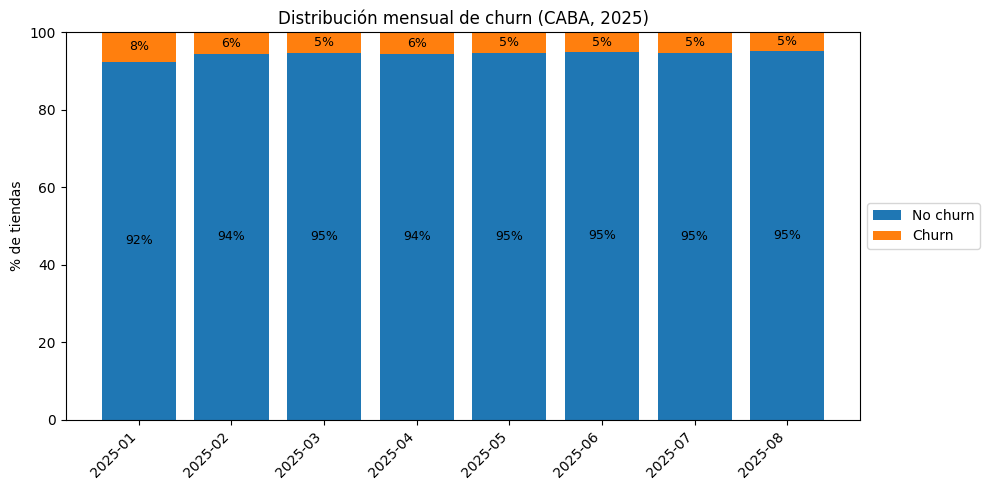

In [8]:
# Visualizamos el desbalance de la variable objetivo 'churn' por mes

df_plot = df_ctx_all.copy()
df_plot = df_plot[df_plot['period_month'] <= pd.Timestamp('2025-08-31')]
df_plot = df_plot[df_plot['churn_unique'].notna()].copy()

pct = (
    df_plot.groupby('period_month')['churn_unique']
    .value_counts(normalize=True)
    .rename('pct')
    .mul(100)
    .reset_index()
    .pivot(index='period_month', columns='churn_unique', values='pct')
    .fillna(0.0)
    .rename(columns={0: 'No churn', 1: 'Churn'})
    .sort_index()
)

# Asegurar que las columnas estén en orden
pct = pct[['No churn', 'Churn']]

# Plot barras apiladas
labels = pct.index.strftime('%Y-%m')
no_churn = pct['No churn'].values
churn = pct['Churn'].values

x = np.arange(len(labels))
width = 0.8

# Plot barras apiladas
plt.figure(figsize=(10, 5))
# barra de No churn
plt.bar(x, no_churn, width, label='No churn')
# barra de Churn (apilada arriba)
plt.bar(x, churn, width, bottom=no_churn, label='Churn')

# Etiquetas de % arriba de cada segmento
for i in range(len(x)):
    # etiqueta "No churn"
    if no_churn[i] > 0:
        plt.text(x[i], no_churn[i] / 2, f"{no_churn[i]:.0f}%", ha='center', va='center', fontsize=9)
    # etiqueta "Churn"
    if churn[i] > 0:
        plt.text(x[i], no_churn[i] + churn[i] / 2, f"{churn[i]:.0f}%", ha='center', va='center', fontsize=9)

plt.xticks(x, labels, rotation=45, ha='right', va='top')
plt.ylabel('% de tiendas')
plt.title('Distribución mensual de churn (CABA, 2025)')
plt.ylim(0, 100)

# Move the legend outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

Creación de variables de lags (hasta t-1) para evitar data leakage. Se hace para las siguientes variables:
- tpn
- gmv
- days_with_orders
- markdown_mean
- avg_shipping_cost
- free_shipping_prop
- connectivity
- total_min_open
- total_minutes_all
- churn_streak

In [9]:
df_ctx_all.columns

Index(['store_id', 'period_month', 'tpn', 'gmv', 'days_with_orders',
       'markdown_mean', 'avg_shipping_cost', 'free_shipping_prop', 'w_tpn_w1',
       'w_tpn_w2', 'w_tpn_w3', 'w_tpn_w4', 'w_tpn_w5', 'w_gmv_w1', 'w_gmv_w2',
       'w_gmv_w3', 'w_gmv_w4', 'w_gmv_w5', 'w_tpn_w6', 'w_gmv_w6', 'churn',
       'churn_streak', 'churn_2m_consec', 'churn_4m_consec_or_more',
       'churn_unique', 'stage', 'created_date', 'segmento', 'comision_actual',
       'in-house_delivery', 'barrio', 'category', 'cooking_time',
       'tiene_otra_app', 'brand_id', 'ciudad', 'total_min_open',
       'total_min_paused', 'total_min_closed', 'total_minutes_all',
       'connectivity', 'created_month', 'age_months'],
      dtype='object')

In [10]:
num_cols = [
    'tpn','gmv','days_with_orders','markdown_mean','avg_shipping_cost',
    'free_shipping_prop','connectivity','total_min_open','total_minutes_all','churn_streak'
]

def add_lag_feats(g, cols, lags=(1,2,3)):
    for c in cols:
        for L in lags:
            g[f'{c}_lag{L}'] = g[c].shift(L)
    return g

def add_roll_feats(g, cols, win=3):
    for c in cols:
        g[f'{c}_roll{win}_mean'] = g[c].shift(1).rolling(win).mean()   # hasta t-1
        g[f'{c}_roll{win}_std']  = g[c].shift(1).rolling(win).std()
    return g

def add_deltas(g):
    # ejemplos sobre tpn
    g['tpn_delta_1m'] = g['tpn_lag1'] - g['tpn_lag2']
    g['tpn_pctchg_1m'] = np.where((g['tpn_lag2']>0),
                                  (g['tpn_lag1']/g['tpn_lag2'] - 1.0),
                                  np.nan)
    # ratio open en t-1
    g['open_rate_lag1'] = np.where(g['total_minutes_all_lag1']>0,
                                   g['total_min_open_lag1']/g['total_minutes_all_lag1'],
                                   np.nan)
    # historial churn
    g['churn_prev'] = g['churn_unique'].shift(1)
    g['en_churn_streak_prev'] = (g['churn_streak'].shift(1) > 0).astype('float')
    return g

df = (df_ctx_all.sort_values(['store_id','period_month'])
        .groupby('store_id', group_keys=False)
        .apply(lambda g: add_lag_feats(g, num_cols))
        .groupby('store_id', group_keys=False)
        .apply(lambda g: add_roll_feats(g, num_cols, win=3))
        .groupby('store_id', group_keys=False)
        .apply(add_deltas))

/tmp/ipykernel_3311/261782932.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: add_lag_feats(g, num_cols))
/tmp/ipykernel_3311/261782932.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: add_roll_feats(g, num_cols, win=3))
/tmp/ipykernel_3311/261782932.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future ve

Encoding de las variables categóricas.

In [11]:
cat_cols = ['segmento', 'barrio', 'category']
for c in cat_cols:
    if c in df_ctx_all.columns:
        df_ctx_all[c] = df_ctx_all[c].astype('category')

Selección final de variables

In [12]:
# Selección final de columnas y limpieza ===
target_col = 'churn_unique'
drop_now = num_cols  # los valores “t” crudos no se usan (evitá leakage)
df = df.drop(columns=drop_now, errors='ignore')  # evita columnas "t" crudas
base_cols = ['store_id','period_month', target_col] + cat_cols
lag_feats = [c for c in df.columns if any(s in c for s in ['_lag','_roll','_std','delta','pctchg','open_rate_lag1','churn_prev','en_churn_streak_prev'])]

Xy = df[base_cols + lag_feats].copy()

# Imputaciones simples + flags
for c in lag_feats:
    if c not in Xy.columns:
        continue
    if str(Xy[c].dtype).startswith('float') or str(Xy[c].dtype).startswith('int'):
        Xy[f'{c}_nanflag'] = Xy[c].isna().astype('int8')
        Xy[c] = Xy[c].fillna(0.0)

/tmp/ipykernel_3311/1659618683.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Xy[f'{c}_nanflag'] = Xy[c].isna().astype('int8')
/tmp/ipykernel_3311/1659618683.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Xy[f'{c}_nanflag'] = Xy[c].isna().astype('int8')
/tmp/ipykernel_3311/1659618683.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-f

# # Resumen Modelo 1 - LightGBM baseline

### Objetivo
Predecir **al inicio de cada mes _t_** la probabilidad de que una tienda entre en **primer mes de churn** durante _t_ (`churn_unique = 1`), usando **solo información disponible hasta _t−1_**.

---

### Población y split temporal
- **Ámbito:** CABA, año **2025**.  
- **Población elegible por mes:** solo tiendas con `period_month ≥ created_month` (evita filas “pre-alta”).  
- **Splits:**  
  - **Train:** 2025-04 a 2025-06  
  - **Validación:** **2025-07**  
  - **Test (hold-out):** **2025-08**  
- **Prevalencia (base rate):** valid **5.26%**, test **4.85%**.

---

### Variable objetivo
- `churn_unique` (binaria 0/1): **1** si el mes es el **primer** mes del streak de churn (si vendió el mes anterior y el actual no vendió); **0** en caso contrario.  
- Se excluyeron filas con `churn_unique` no definido (NaN).

---

### Variables y transformaciones (as-of _t−1_)
- **Numéricas base:** `tpn`, `gmv`, `days_with_orders`, `markdown_mean`, `avg_shipping_cost`, `free_shipping_prop`, `connectivity` (def.: `total_min_open/total_minutes_all`), `total_min_open`, `total_minutes_all`, `churn_streak`.  
- **Derivadas (todas “cerradas a la izquierda”):**
  - **Lags:** `_lag1`, `_lag2`, `_lag3`
  - **Rolling 3m (sobre _t−1_):** `_roll3_mean`, `_roll3_std`
  - **Tendencias:** `tpn_delta_1m = tpn_lag1 − tpn_lag2`, `tpn_pctchg_1m`
  - **Operativas:** `open_rate_lag1 = total_min_open_lag1 / total_minutes_all_lag1`
  - **Historial churn:** `churn_prev = churn_unique_lag1`, `en_churn_streak_prev = (churn_streak_lag1 > 0)`
- **Categóricas:** `segmento`, `barrio`, `category` (dtype `category`).  
- **Variables descartadas:** `stage` del mes _t_ (leakage), `si_ios_prop`, `si_meli_prop`, `si_other_prop`, `store_type`.  
- **Imputación:** `fillna(0.0)` en lags/rollings numéricos + **flags de imputación** `*_nanflag`.

---

### Modelo y entrenamiento
- **Algoritmo:** LightGBM (GBDT, `objective='binary'`).  
- **Parámetros base:** `learning_rate=0.05`, `num_leaves≈31`, `feature_fraction=0.9`, `bagging_fraction=0.9`, `min_child_samples=50`, `reg_lambda=5.0`.  
- **Desbalance:** `scale_pos_weight = (negativos/positivos)` calculado en train.  
- **Callbacks:** early stopping y logging.  
- **Selección de umbral:** por **F2** en validación (privilegia recall). Umbral elegido **0.5421** y aplicado tal cual en test.

---

### Métricas principales (sobre toda la base, sin Top-K)

| Split | Threshold | Precision | Recall | F2 | AUC | AUPRC | Base rate |
|---|---:|---:|---:|---:|---:|---:|---:|
| **Valid (Jul-2025)** | 0.5421 | **0.326** | **0.760** | **0.600** | **0.925** | **0.401** | 0.0526 |
| **Test  (Ago-2025)** | 0.5421 | **0.311** | **0.725** | — | **0.931** | **0.371** | 0.0485 |

**Matriz de confusión (Valid):** TN=3012, FP=287, FN=44, TP=139  
**Matriz de confusión (Test):**  TN=3277, FP=292, FN=50,  TP=132

> **Lectura:** Con base rate ~5%, el **AUPRC 0.37–0.40** implica un **lift x7–8** vs. azar. El umbral orientado a recall captura ~**73–76%** de los onsets a costa de **precisión ~0.31–0.33** (falsos positivos operativos).

---

### Chequeos de fuga (data leakage)
- **Población elegible** por mes (no “pre-alta”).  
- **Features as-of _t−1_** (lags/rollings con `shift(1)` sobre `store_id, period_month` ordenados).  
- **Exclusión explícita** de `stage` en _t_ (principal fuente de fuga).  
- **Val/Test** con métricas muy similares ⇒ sin sobreajuste evidente y **sin señales de leakage** remanente.

---

### Análisis por streak en mes _t_ (Valid Jul-2025)
- **TP:** 100% con `churn_streak>0` (coherente con onset).  
- **FN:** 100% con `churn_streak>0` (onsets que el modelo no capturó).  
- **FP:** 100% con `churn_streak=0` (alarmas de onset que **no** se materializaron).  
- **TN:** 31.7% con `streak>0` (continuaciones de churn correctamente no marcadas como onset) y 68.3% sin streak.

**Mayor punto de dolor:** **falsos positivos de onset** (tiendas sin streak en _t_ que el modelo marca como riesgo). Esto afecta la **precisión** (~0.31–0.33) más que el recall.

---

### Próximos pasos recomendados
1. **Umbral por ROI** (en vez de F2): elegir el threshold que maximiza **valor esperado** dado costo por contacto y beneficio por churn evitado.  
2. **Tuning de desbalance:** barrer `scale_pos_weight` alrededor del ratio empírico (±20%).  
3. **Más señal “pre-churn” para bajar FP manteniendo recall:**  
   - Tendencias de actividad (`days_with_orders`/`tpn`: rollings, deltas, %chg),  
   - Conectividad (`connectivity_lag1`, `connectivity_roll3_mean`) e **interacciones** con actividad.  
4. **Regla post-modelo suave** (opcional): mantener `yhat=1` solo si (conectividad baja **o** tendencia negativa **o** caída en `days_with_orders`), monitorizando el trade-off recall/precisión.  
5. **Calibración** (si se comunican probabilidades): Isotonic en valid y aplicación en test.

In [13]:
def _predict_proba_pos(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:,1]
    return model.predict(X, num_iteration=getattr(model, "best_iteration_", getattr(model, "best_iteration", None)))

def _pick_threshold_by_fbeta(y_true, y_score, beta=2.0):
    y = pd.Series(y_true).astype(int).values
    s = np.asarray(y_score)
    p, r, t = precision_recall_curve(y, s)
    t = np.r_[t, 1.0]
    b2 = beta**2
    f = (1+b2) * (p*r) / (b2*p + r + 1e-12)
    i = np.nanargmax(f)
    return float(t[i]), float(p[i]), float(r[i]), float(f[i])

def train_and_predict_lgbm(
    Xy, train_mask, valid_mask, test_mask,
    *,
    target_col="churn_unique",
    id_cols=("store_id","period_month"),
    cat_cols=("segmento","barrio","category"),
    features_to_use=None,     # lista explícita de features a usar; si None -> auto
    params=None,              # dict LightGBM; si None uso defaults
    num_boost_round=2000,
    early_stopping_rounds=200,
    log_period=100,
    auto_scale_pos_weight=True,
    scale_pos_weight=None,
    output_mode="binary",     # "binary" o "proba"
    threshold_strategy="f2",  # si output_mode="binary": "f2" o "fixed"
    fixed_threshold=None,     # usado si threshold_strategy="fixed"
    beta=2.0                  # usado si threshold_strategy="f2"
):
    """
    Entrena LightGBM y devuelve probabilidades y (opcional) predicción binaria.
    """
    # 1) preparar datos
    data = Xy.copy()
    # tipar categóricas
    for c in cat_cols:
        if c in data.columns:
            data[c] = data[c].astype("category")

    # features
    if features_to_use is None:
        excl = set(id_cols) | {target_col}
        features = [c for c in data.columns if c not in excl]
    else:
        features = list(features_to_use)

    features = [c for c in features if c not in (set(id_cols) | {target_col})]

    # splits
    X_train, y_train = data.loc[train_mask, features], data.loc[train_mask, target_col]
    X_valid, y_valid = data.loc[valid_mask, features], data.loc[valid_mask, target_col]
    X_test,  y_test  = data.loc[test_mask,  features], data.loc[test_mask,  target_col]

    # Guards de sanidad
    if X_test.shape[0] == 0:
        raise ValueError("X_test está vacío: el test_mask no seleccionó filas. No filtres NaN del target para el mes de predicción y asegurá que generaste features para ese mes.")
    assert y_train.notna().all(), "y_train tiene NaN; ajustá el train_mask para excluirlos."
    assert y_valid.notna().all(), "y_valid tiene NaN; ajustá el valid_mask para excluirlos."

    cat_features = [c for c in cat_cols if c in X_train.columns]

    # desbalance
    if auto_scale_pos_weight and scale_pos_weight is None:
        pos = max(1, int(y_train.sum()))
        neg = len(y_train) - pos
        scale_pos_weight = neg/pos

    # parámetros
    '''base_params = dict(
        objective="binary",
        metric=["auc","average_precision"],
        boosting_type="gbdt",
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_data_in_leaf=50,
        feature_fraction=0.9,
        bagging_fraction=0.9,
        bagging_freq=1,
        lambda_l1=0.0,
        lambda_l2=5.0,
        verbose=-1
    )'''

    base_params = dict(
        objective='binary',
        metric=['auc','average_precision'],
        boosting_type='gbdt',
        learning_rate=0.05,

        # Capacidad más contenida
        num_leaves=20, #antes: 31,          # si hay mucho ruido, probá 15–31
        max_depth=8,            # limita la profundidad
        min_data_in_leaf=150, # antes: 100,   # (subilo desde 50) frena splits en grupos chicos
        min_gain_to_split=0.02,  #antes: 0.01, # requiere ganancia mínima para dividir

        # Bagging/col-subsampling
        feature_fraction=0.7, #antes:0.8,   # menos features por árbol
        bagging_fraction=0.8,
        bagging_freq=1,

        # L2 más fuerte
        lambda_l2=30.0, #antes: 20.0,         # (antes 5.0)
        # lambda_l1=0.0,

        # Desbalance
        # scale_pos_weight = el que ya calculás
        verbose=-1
    )

    if scale_pos_weight is not None:
        base_params["scale_pos_weight"] = scale_pos_weight
    if params:
        base_params.update(params)

    lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_features, free_raw_data=False)
    lgb_valid = lgb.Dataset(X_valid, label=y_valid, categorical_feature=cat_features, reference=lgb_train, free_raw_data=False)


    evals_result = {}


    callbacks = [lgb.early_stopping(stopping_rounds=early_stopping_rounds),
             lgb.log_evaluation(period=log_period),
             lgb.record_evaluation(evals_result)]


    model = lgb.train(
        base_params, lgb_train,
        num_boost_round=num_boost_round,
        valid_sets=[lgb_train, lgb_valid],
        valid_names=["train","valid"],
        callbacks=callbacks
    )

    # 2) probabilidades
    valid_prob = _predict_proba_pos(model, X_valid)
    test_prob  = _predict_proba_pos(model, X_test)


    out = {
        "model": model,
        "features": features,
        "cat_features": cat_features,
        "y_train": y_train, "y_valid": y_valid, "y_test": y_test,
        "valid_prob": valid_prob, "test_prob": test_prob,
        "params_used": base_params,
        "evals_result": evals_result

    }

    # 3) predicción binaria (opcional)
    if output_mode == "binary":
        if threshold_strategy == "f2":
            thr, p_f2, r_f2, f2 = _pick_threshold_by_fbeta(y_valid, valid_prob, beta=beta)
        elif threshold_strategy == "fixed":
            if fixed_threshold is None:
                raise ValueError("Debes pasar fixed_threshold cuando threshold_strategy='fixed'")
            thr = float(fixed_threshold)
            p_f2 = r_f2 = f2 = None
        else:
            raise ValueError("threshold_strategy debe ser 'f2' o 'fixed'")

        out.update({
            "threshold": thr,
            "metrics_valid_f2": dict(precision=p_f2, recall=r_f2, F2=f2) if p_f2 is not None else None,
            "valid_pred_bin": (valid_prob >= thr).astype(int),
            "test_pred_bin":  (test_prob  >= thr).astype(int)
        })

    return out


Entranamiento del modelo

In [14]:
# Split temporal
train_mask = Xy['period_month'].between('2025-04-01','2025-06-30') & Xy['churn_unique'].notna()
valid_mask = Xy['period_month'].between('2025-07-01','2025-07-31') & Xy['churn_unique'].notna()
test_mask  = Xy['period_month'].between('2025-08-01','2025-08-31')

# sanity: tamaños y fechas de cada split
print("Train range:", Xy.loc[train_mask, 'period_month'].min(), "→", Xy.loc[train_mask, 'period_month'].max(), 
      "n=", sum(train_mask))
print("Valid range:", Xy.loc[valid_mask, 'period_month'].min(), "→", Xy.loc[valid_mask, 'period_month'].max(), 
      "n=", sum(valid_mask))
print("Test  range:", Xy.loc[test_mask,  'period_month'].min(), "→", Xy.loc[test_mask,  'period_month'].max(), 
      "n=", sum(test_mask))

run_bin = train_and_predict_lgbm(
    Xy, train_mask, valid_mask, test_mask,
    target_col="churn_unique",
    cat_cols=("segmento","barrio","category"),
    features_to_use=None,        # usa todas las columnas (menos ids y target)
    output_mode="binary",        # ← binario
    threshold_strategy="f2",     # ← elige umbral por F2 (beta=2)
    beta=2.0
)

y_valid    = run_bin["y_valid"]
y_test     = run_bin["y_test"]
valid_pred = run_bin["valid_prob"]   # <- probabilidades en VALID (no binario)
test_pred  = run_bin["test_prob"]    # <- probabilidades en TEST  (no binario)

# Si querés usar el mismo umbral que eligió la función (por F2):
thr_f2 = run_bin["threshold"]

Train range: 2025-04-01 00:00:00 → 2025-06-01 00:00:00 n= 8890
Valid range: 2025-07-01 00:00:00 → 2025-07-01 00:00:00 n= 3482
Test  range: 2025-08-01 00:00:00 → 2025-08-01 00:00:00 n= 5293
Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.969513	train's average_precision: 0.587789	valid's auc: 0.924751	valid's average_precision: 0.409827
[200]	train's auc: 0.987517	train's average_precision: 0.757847	valid's auc: 0.922045	valid's average_precision: 0.408893
Early stopping, best iteration is:
[54]	train's auc: 0.953056	train's average_precision: 0.489031	valid's auc: 0.926333	valid's average_precision: 0.419622


Evaluación de performance del modelo

In [15]:
# ---------- helpers de limpieza/alineación ----------
def _align_dropna(y_true, y_score):
    y = pd.Series(y_true).reset_index(drop=True)
    s = np.asarray(y_score)
    mask = y.notna().values
    return y[mask].astype(int).values, s[mask]

# ---------- selección de umbral por F-beta (favor recall) ----------
def pick_threshold_by_fbeta(y_true, y_score, beta=2.0):
    y, s = _align_dropna(y_true, y_score)
    p, r, t = precision_recall_curve(y, s)
    t = np.r_[t, 1.0]  # igualar largo
    beta2 = beta**2
    fbeta = (1+beta2) * (p*r) / (beta2*p + r + 1e-12)
    i = np.nanargmax(fbeta)
    return float(t[i]), float(p[i]), float(r[i]), float(fbeta[i])

# ---------- evaluación completa a un umbral ----------
def evaluate_at_threshold(y_true, y_score, thr):
    y, s = _align_dropna(y_true, y_score)
    y_hat = (s >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_hat, labels=[0,1]).ravel()
    metrics = {
        "threshold": round(thr, 4),
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
        "precision": precision_score(y, y_hat, zero_division=0),
        "recall": recall_score(y, y_hat, zero_division=0),
        "specificity": tn / (tn + fp) if (tn+fp)>0 else 0.0,
        "f1": f1_score(y, y_hat, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y, y_hat),
        "AUC": roc_auc_score(y, s),
        "AUPRC": average_precision_score(y, s),
        "base_rate": y.mean()
    }
    cm = np.array([[tn, fp],[fn, tp]])
    return metrics, cm

# ---------- gráfico de matriz de confusión ----------

def plot_confusion(cm, title="Matriz de confusión", percent=False):
    """
    cm: np.array([[TN, FP],[FN, TP]])
    percent: si True, anota porcentajes de cada celda sobre el total
    """
    vmin, vmax = 0, cm.max() if cm.size else 1
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap('RdYlGn')
    

    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    im = ax.imshow(cm, cmap=cmap, norm=norm)
    ax.set_title(title)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['No churn', 'Churn'])
    ax.set_yticklabels(['No churn', 'Churn'])

    total = cm.sum()
    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            txt_color = "white" if norm(val) > 0.5 else "black"
            label = f"{val:,}"
            if percent and total > 0:
                label += f"\n({val/total:.1%})"
            ax.text(j, i, label, ha="center", va="center", fontsize=11, color=txt_color, fontweight='bold' if i==j else 'normal')

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel('Frecuencia', rotation=90, labelpad=10)
    plt.tight_layout()
    plt.show()

Umbral elegido (F2): 0.5993
VALID → P=0.313 | R=0.803 | F2=0.611

— VALID —


,valor
threshold,0.599300
TP,147.000000
FP,323.000000
TN,2976.000000
FN,36.000000
precision,0.312766
recall,0.803279
specificity,0.902092
f1,0.450230
balanced_accuracy,0.852685



— TEST —


,valor
threshold,0.599300
TP,135.000000
FP,335.000000
TN,3234.000000
FN,47.000000
precision,0.287234
recall,0.741758
specificity,0.906136
f1,0.414110
balanced_accuracy,0.823947


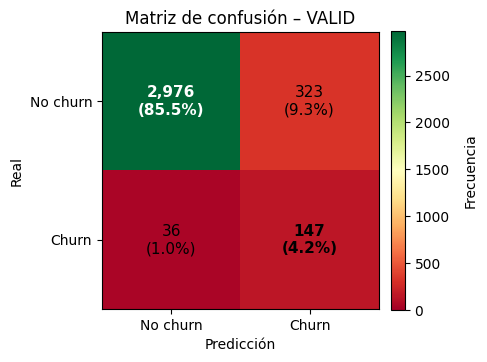

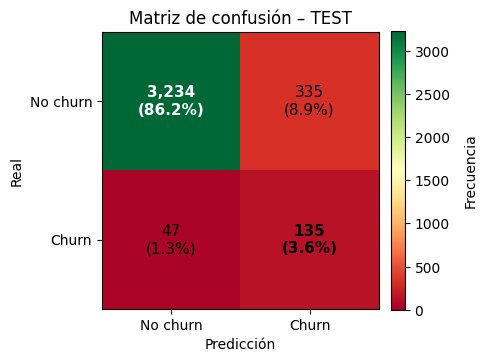

In [16]:
# ===================== uso =====================

# 1) umbral por F2 en VALID
thr_f2, p_f2, r_f2, f2 = pick_threshold_by_fbeta(y_valid, valid_pred, beta=2.0)

print(f"Umbral elegido (F2): {thr_f2:.4f}")
print(f"VALID → P={p_f2:.3f} | R={r_f2:.3f} | F2={f2:.3f}")

# 2) Métricas  (VALID / TEST)
valid_metrics, valid_cm = evaluate_at_threshold(y_valid, valid_pred, thr_f2)
test_metrics,  test_cm  = evaluate_at_threshold(y_test,  test_pred,  thr_f2)

def _nice(df_metrics):
    df = pd.DataFrame([df_metrics]).T
    df.columns = ["valor"]
    for k in ["precision","recall","specificity","f1","balanced_accuracy","AUC","AUPRC","base_rate"]:
        if k in df.index:
            df.loc[k, "valor"] = float(df.loc[k, "valor"])
    return df

print("\n— VALID —")
display(_nice(valid_metrics))

print("\n— TEST —")
display(_nice(test_metrics))

# 3) Matrices de confusión
plot_confusion(valid_cm, title="Matriz de confusión – VALID", percent=True)
plot_confusion(test_cm,  title="Matriz de confusión – TEST",  percent=True)

Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.969513	train's average_precision: 0.587789	valid's auc: 0.924751	valid's average_precision: 0.409827
[200]	train's auc: 0.987517	train's average_precision: 0.757847	valid's auc: 0.922045	valid's average_precision: 0.408893
Early stopping, best iteration is:
[54]	train's auc: 0.953056	train's average_precision: 0.489031	valid's auc: 0.926333	valid's average_precision: 0.419622


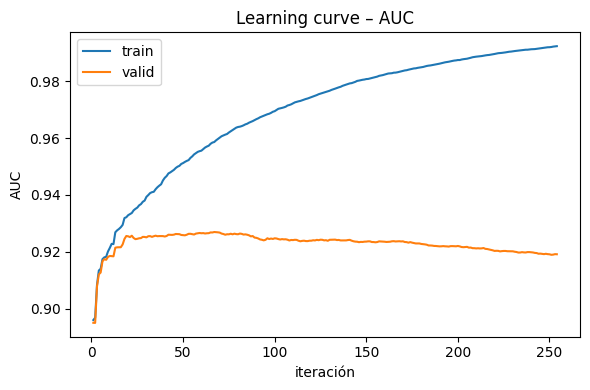

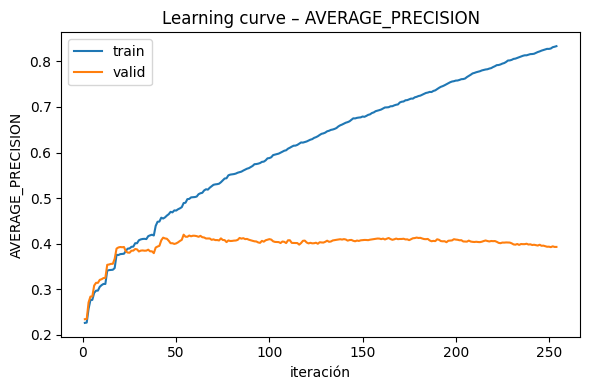

In [17]:
# Entrena una vez con tus masks actuales y grafica evals_result_
run_tmp = train_and_predict_lgbm(
    Xy, train_mask, valid_mask, test_mask,
    target_col="churn_unique",
    cat_cols=("segmento","barrio","category"),
    features_to_use=None,
    output_mode="proba",              # solo probas
    threshold_strategy="f2",
    beta=2.0
)

ev = run_tmp["evals_result"]

# Plot por métrica
import matplotlib.pyplot as plt

for metric in ["auc","average_precision"]:
    if "train" in ev and metric in ev["train"]:
        iters = range(1, len(ev["train"][metric]) + 1)
        plt.figure(figsize=(6,4))
        plt.plot(iters, ev["train"][metric], label="train")
        plt.plot(iters, ev["valid"][metric], label="valid")
        plt.xlabel("iteración")
        plt.ylabel(metric.upper())
        plt.title(f"Learning curve – {metric.upper()}")
        plt.legend()
        plt.tight_layout()
        plt.show()


Feature Importance

,feature,gain,split,gain_norm
9,days_with_orders_lag1,49368.016469,66,0.499920
3,tpn_lag1,18251.520070,49,0.184822
1,barrio,6548.472264,95,0.066312
6,gmv_lag1,4554.552643,55,0.046121
2,category,4051.870861,74,0.041031
53,tpn_delta_1m,2798.348724,36,0.028337
15,avg_shipping_cost_lag1,1671.118896,42,0.016922
0,segmento,1671.080118,18,0.016922
36,gmv_roll3_std,1082.525003,24,0.010962
7,gmv_lag2,809.909803,21,0.008201


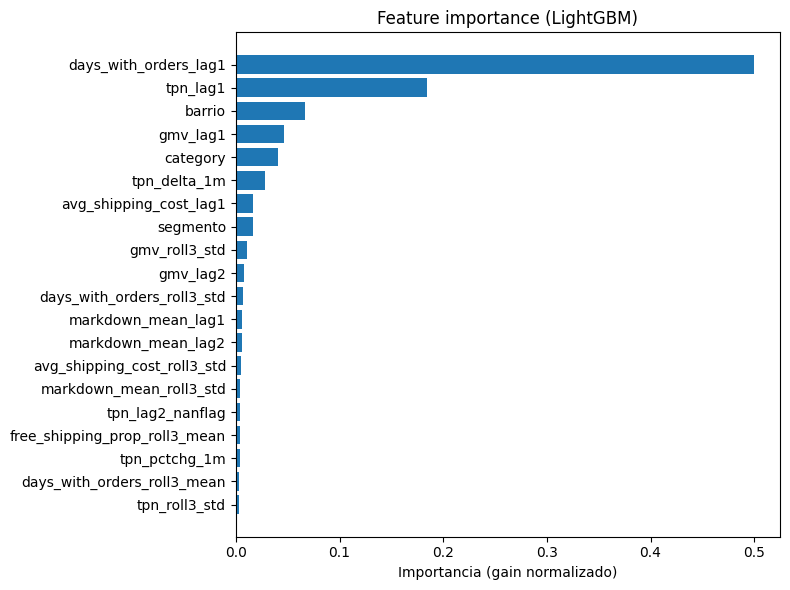

In [18]:
def get_booster(model):
    # Soporta lgb.train (Booster) y LGBMClassifier (wrapper)
    return getattr(model, "booster_", model)

def feature_importance_df(model, feature_names):
    booster = get_booster(model)
    imp_gain  = booster.feature_importance(importance_type='gain')
    imp_split = booster.feature_importance(importance_type='split')
    df_imp = pd.DataFrame({
        "feature": feature_names,
        "gain": imp_gain,
        "split": imp_split
    }).sort_values("gain", ascending=False)
    df_imp["gain_norm"] = df_imp["gain"] / (df_imp["gain"].sum() if df_imp["gain"].sum() > 0 else 1)
    return df_imp

# construir el DF de importancia (usá tu lista 'features')
df_imp = feature_importance_df(run_tmp["model"], run_tmp["features"])
display(df_imp.head(30))  # top 30 por gain

# gráfico (top 20 por gain normalizado)
top = df_imp.head(20).iloc[::-1]  # invertimos para barh
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["gain_norm"])
plt.xlabel("Importancia (gain normalizado)")
plt.title("Feature importance (LightGBM)")
plt.tight_layout()
plt.show()


Probamos haciendo Tail-pruning automático por importancia: drop de variables con gain_norm < 0.003 --> MODELO ELEGIDO FINAL !!!

Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.968136	train's average_precision: 0.566158	valid's auc: 0.926078	valid's average_precision: 0.41355
[200]	train's auc: 0.985353	train's average_precision: 0.720089	valid's auc: 0.923118	valid's average_precision: 0.414249
Early stopping, best iteration is:
[35]	train's auc: 0.943344	train's average_precision: 0.429465	valid's auc: 0.927084	valid's average_precision: 0.399335


,0
threshold,0.584800
TP,139.000000
FP,283.000000
TN,3016.000000
FN,44.000000
precision,0.329384
recall,0.759563
specificity,0.914216
f1,0.459504
balanced_accuracy,0.836890


,0
threshold,0.584800
TP,131.000000
FP,295.000000
TN,3274.000000
FN,51.000000
precision,0.307512
recall,0.719780
specificity,0.917344
f1,0.430921
balanced_accuracy,0.818562


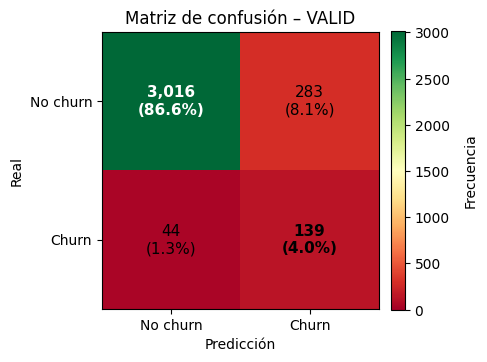

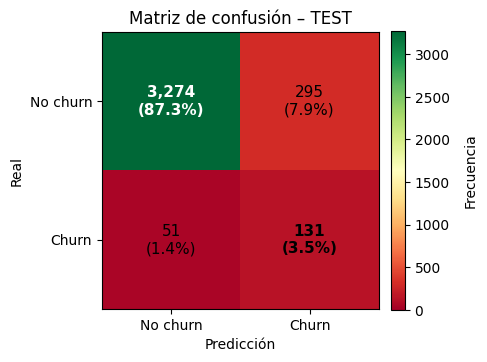

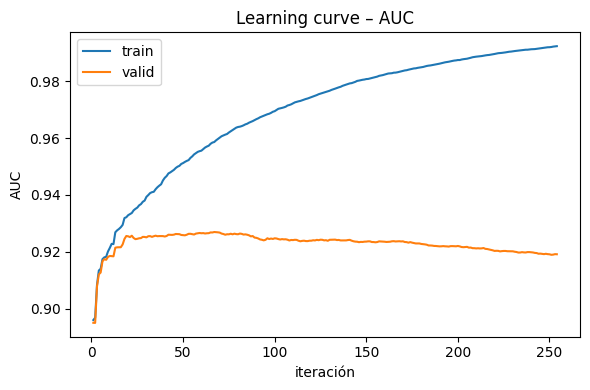

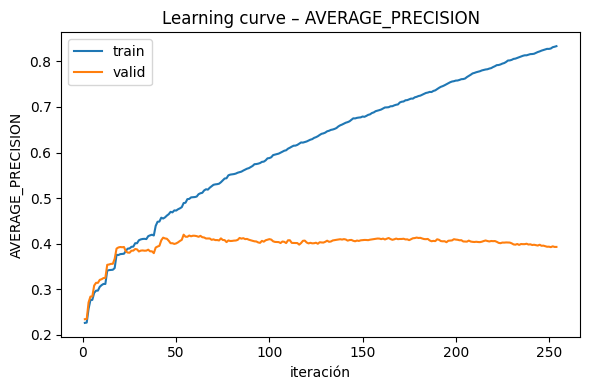

In [19]:
# df_imp ya lo tenés del feature importance
to_drop = df_imp.loc[df_imp['gain_norm'] < 0.003, 'feature'].tolist()

features_all = run_bin["features"]  # o la lista que uses ahora
features_pruned = [f for f in features_all if f not in to_drop]

run_pruned = train_and_predict_lgbm(
    Xy, train_mask, valid_mask, test_mask,
    target_col="churn_unique",
    cat_cols=("segmento","barrio","category"),
    features_to_use=features_pruned,   # ← usar lista sin las de baja importancia
    output_mode="proba"                # o "binary" si querés
)

# Evaluación con tu helper habitual
thr_f2, p_f2, r_f2, f2 = pick_threshold_by_fbeta(run_pruned["y_valid"], run_pruned["valid_prob"], beta=2.0)
valid_metrics, valid_cm = evaluate_at_threshold(run_pruned["y_valid"], run_pruned["valid_prob"], thr_f2)
test_metrics,  test_cm  = evaluate_at_threshold(run_pruned["y_test"],  run_pruned["test_prob"],  thr_f2)
display(pd.DataFrame([valid_metrics]).T); display(pd.DataFrame([test_metrics]).T)
# 3) Matrices de confusión
plot_confusion(valid_cm, title="Matriz de confusión – VALID", percent=True)
plot_confusion(test_cm,  title="Matriz de confusión – TEST",  percent=True)


ev = run_tmp["evals_result"]

for metric in ["auc","average_precision"]:
    if "train" in ev and metric in ev["train"]:
        iters = range(1, len(ev["train"][metric]) + 1)
        plt.figure(figsize=(6,4))
        plt.plot(iters, ev["train"][metric], label="train")
        plt.plot(iters, ev["valid"][metric], label="valid")
        plt.xlabel("iteración")
        plt.ylabel(metric.upper())
        plt.title(f"Learning curve – {metric.upper()}")
        plt.legend()
        plt.tight_layout()
        plt.show()


,feature,gain,split,gain_norm
3,tpn_lag1,37734.452491,41,0.429972
6,days_with_orders_lag1,28451.004045,40,0.324190
1,barrio,5515.296227,61,0.062845
4,gmv_lag1,5018.107753,34,0.057180
2,category,2335.514668,37,0.026612
0,segmento,1894.189673,17,0.021584
17,tpn_delta_1m,1859.376715,26,0.021187
7,markdown_mean_lag1,692.072104,11,0.007886
11,gmv_roll3_std,658.514429,14,0.007504
5,gmv_lag2,606.889482,17,0.006915


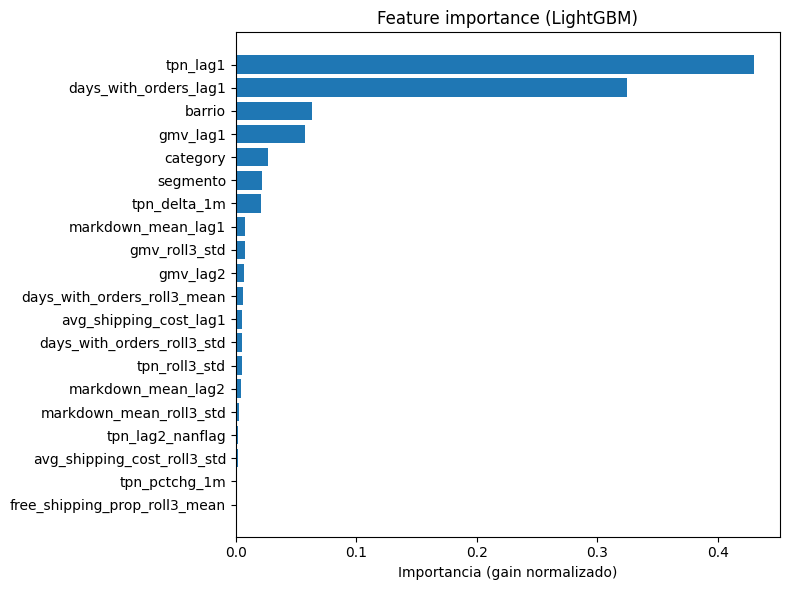

In [20]:
# construir el DF de importancia (usá tu lista 'features')
df_imp = feature_importance_df(run_pruned["model"], run_pruned["features"])
display(df_imp.head(30))  # top 30 por gain

# gráfico (top 20 por gain normalizado)
top = df_imp.head(20).iloc[::-1]  # invertimos para barh
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["gain_norm"])
plt.xlabel("Importancia (gain normalizado)")
plt.title("Feature importance (LightGBM)")
plt.tight_layout()
plt.show()

In [21]:
!pip install shap


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


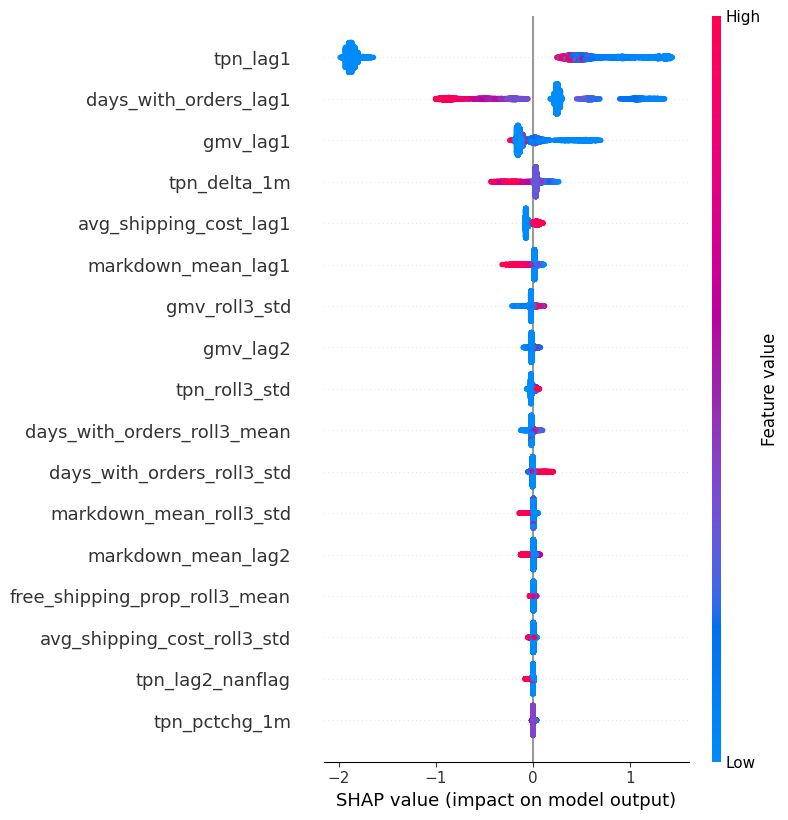

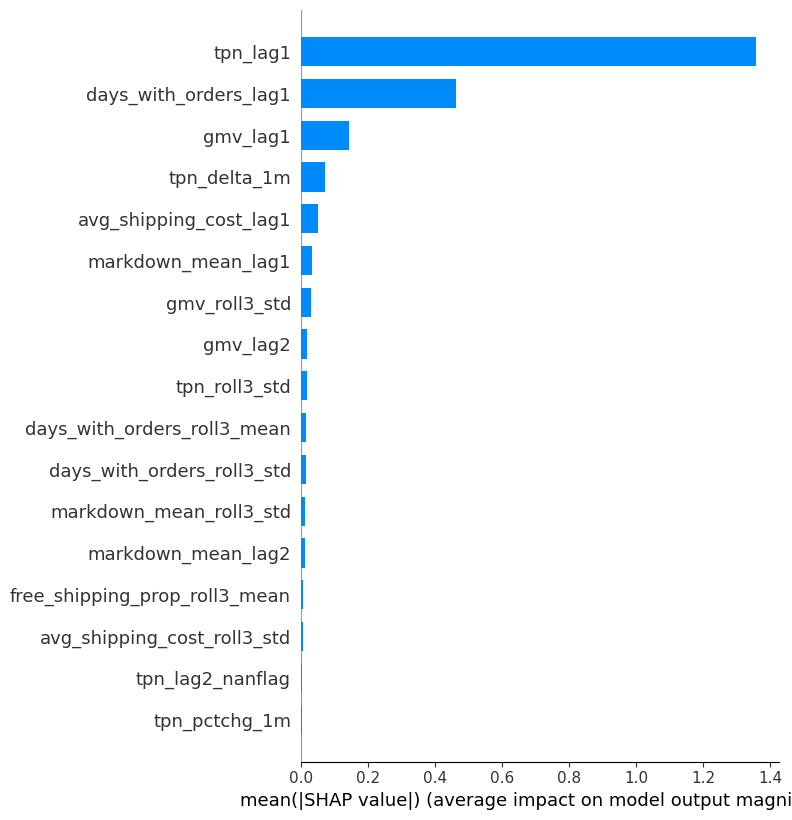

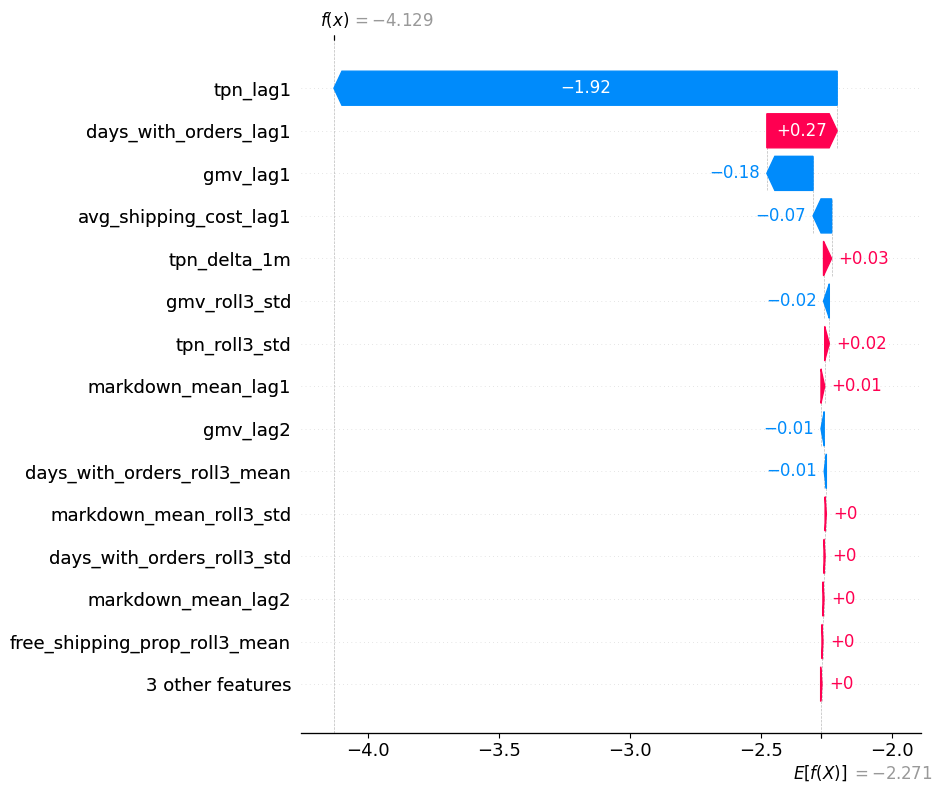

Listo: SHAP en TEST (gráficos sin categóricas) guardados.


In [22]:
# ==== SHAP en TEST, excluyendo categóricas de los gráficos ====

import shap

cat_cols = ("segmento","barrio","category")   # columnas categóricas

# 1) Construir matriz de evaluación: TEST
X_test = Xy.loc[test_mask, features_pruned].copy()
# (opcional) asegurar dtypes categóricos para predecir igual que en train
for c in cat_cols:
    if c in X_test.columns:
        X_test[c] = X_test[c].astype("category")

# 2) Modelo
model = run_pruned.get("model", run_pruned.get("booster", None))
if model is None:
    raise ValueError("No se encontró el modelo en run_pruned['model'] ni en run_pruned['booster'].")

# 3) SHAP values (rápido con pred_contrib)
try:
    shap_values_full = model.predict(X_test, pred_contrib=True)  # [n_samples, n_features+1]
    expected_value = shap_values_full[:, -1].mean()               # bias promedio
    shap_values = shap_values_full[:, :-1]                        # quitamos bias para plots
except TypeError:
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_test)
    shap_values = sv[1] if isinstance(sv, list) else sv           # clase positiva
    expected_value = (explainer.expected_value[1] 
                      if isinstance(explainer.expected_value,(list,np.ndarray)) 
                      else explainer.expected_value)

# 4) Filtrar para gráficos: solo NO categóricas
noncat_cols = [c for c in X_test.columns if c not in cat_cols]
idx_noncat  = [i for i, c in enumerate(X_test.columns) if c in noncat_cols]

# --- Summary beeswarm (solo numéricas) ---
shap.summary_plot(shap_values[:, idx_noncat], X_test[noncat_cols],
                  show=True, plot_type="dot", max_display=25)

# --- Summary bar (solo numéricas) ---
shap.summary_plot(shap_values[:, idx_noncat], X_test[noncat_cols],
                  show=True, plot_type="bar", max_display=25)

# 5) Waterfall para un caso individual (solo numéricas)
idx = X_test.index[0]                     # elegí un caso representativo (TP/FN)
row_pos = np.where(X_test.index == idx)[0][0]
shap.plots._waterfall.waterfall_legacy(
    expected_value=expected_value,
    shap_values=shap_values[row_pos, idx_noncat],
    feature_names=noncat_cols,
    max_display=15
)

# 6) Guardar imágenes
plt.figure(); shap.summary_plot(shap_values[:, idx_noncat], X_test[noncat_cols],
                                show=False, plot_type="dot", max_display=25)
plt.tight_layout(); plt.savefig("shap_summary_beeswarm_TEST_noncats.png", dpi=200); plt.close()

plt.figure(); shap.summary_plot(shap_values[:, idx_noncat], X_test[noncat_cols],
                                show=False, plot_type="bar", max_display=25)
plt.tight_layout(); plt.savefig("shap_summary_bar_TEST_noncats.png", dpi=200); plt.close()

fig = plt.gcf(); fig.savefig("shap_waterfall_case_TEST_noncats.png", dpi=200); plt.close(fig)

print("Listo: SHAP en TEST (gráficos sin categóricas) guardados.")



In [23]:
# =========================
# Helper: eval_df con churn_streak de mes actual desde df_ctx_all
# =========================
def make_eval_df(Xy, mask, y_score_series, df_ctx_all, thr, label_month):
    """
    Xy: DataFrame maestro (incluye store_id, period_month, churn_unique)
    mask: boolean mask (VALID o TEST)
    y_score_series: pd.Series con probabilidades (índice = Xy.index[mask])
    df_ctx_all: DataFrame con columnas ['store_id','period_month','churn_streak']
    thr: umbral para binarizar
    label_month: 'YYYY-MM' (se filtra por ese mes)
    """
    # base con claves + target del subconjunto
    base = Xy.loc[mask, ['store_id','period_month','churn_unique']].copy()
    base = base.rename(columns={'churn_unique':'y'})

    # asegurar tipos fecha
    base['period_month'] = pd.to_datetime(base['period_month'])
    ctx = df_ctx_all[['store_id','period_month','churn_streak']].copy()
    ctx['period_month'] = pd.to_datetime(ctx['period_month'])

    # anexar score y pred binaria (alineado por índice)
    # y_score_series debe tener índice = Xy.index[mask]
    base = base.join(y_score_series.rename('score'))
    base['yhat'] = (base['score'] >= thr).astype(int)

    # merge para traer churn_streak del mes actual
    eval_df = base.merge(ctx, on=['store_id','period_month'], how='left')

    # construir flag de streak (t)
    churn_streak_num = pd.to_numeric(eval_df['churn_streak'], errors='coerce').fillna(0)
    eval_df['streak_flag'] = np.where(churn_streak_num > 0, 'Con streak (>0)', 'Sin streak (=0)')

    # clasificar casos
    def classify(row):
        if row['y']==1 and row['yhat']==1: return 'TP'
        if row['y']==1 and row['yhat']==0: return 'FN'
        if row['y']==0 and row['yhat']==1: return 'FP'
        return 'TN'
    eval_df['clase'] = eval_df.apply(classify, axis=1)

    # filtrar por el mes exacto (YYYY-MM)
    if isinstance(label_month, str):
        pmask = (eval_df['period_month'].dt.to_period('M') == pd.Period(label_month))
        eval_df = eval_df.loc[pmask].copy()

    # asegurar y válida (descartar NaN si existieran)
    eval_df = eval_df[eval_df['y'].notna()].copy()
    eval_df['y'] = eval_df['y'].astype(int)

    return eval_df

# =========================
# Preparar probabilidades desde run_pruned (sin predecir de nuevo)
# =========================
# Armamos series con índices alineados a Xy
valid_scores = pd.Series(run_pruned["valid_prob"], index=Xy.index[valid_mask])
test_scores  = pd.Series(run_pruned["test_prob"],  index=Xy.index[test_mask])

# Elegí el umbral que estés usando (por ejemplo, el fijado en evaluación)
thr = 0.5946  # o thr_f2 si lo calculaste por F-beta

# =========================
# Construir eval_df para VALID (Julio 2025) y TEST (Agosto 2025)
# =========================
eval_valid = make_eval_df(
    Xy=Xy,
    mask=valid_mask,
    y_score_series=valid_scores,
    df_ctx_all=df_ctx_all,
    thr=thr,
    label_month='2025-07'
)

eval_test = make_eval_df(
    Xy=Xy,
    mask=test_mask,
    y_score_series=test_scores,
    df_ctx_all=df_ctx_all,
    thr=thr,
    label_month='2025-08'
)

# =========================
# Tablas: clase (TP/FN/FP/TN) × streak_flag
# =========================
def streak_table(eval_df, title):
    cnt = (eval_df
           .groupby(['clase','streak_flag'])
           .size()
           .unstack(fill_value=0)
           .reindex(index=['TP','FN','FP','TN']))  # orden fijo
    pct = (cnt.div(cnt.sum(axis=1), axis=0) * 100).round(1)
    print(f"\n{title} — Conteos")
    display(cnt)
    print(f"{title} — Porcentajes dentro de cada clase")
    display(pct)
    return cnt, pct

cnt_valid, pct_valid = streak_table(eval_valid, "VALID (Jul 2025)")
cnt_test,  pct_test  = streak_table(eval_test,  "TEST  (Ago 2025)")



VALID (Jul 2025) — Conteos


streak_flag,Con streak (>0),Sin streak (=0)
clase,,
TP,136,0
FN,47,0
FP,0,277
TN,954,2068


VALID (Jul 2025) — Porcentajes dentro de cada clase


streak_flag,Con streak (>0),Sin streak (=0)
clase,,
TP,100.0,0.0
FN,100.0,0.0
FP,0.0,100.0
TN,31.6,68.4



TEST  (Ago 2025) — Conteos


streak_flag,Con streak (>0),Sin streak (=0)
clase,,
TP,131,0
FN,51,0
FP,0,288
TN,1080,2201


TEST  (Ago 2025) — Porcentajes dentro de cada clase


streak_flag,Con streak (>0),Sin streak (=0)
clase,,
TP,100.0,0.0
FN,100.0,0.0
FP,0.0,100.0
TN,32.9,67.1


In [24]:
MES_OBJETIVO = "2025-08"
THR = 0.5946
CAT_COLS = ("segmento","category","barrio")
NUM_COLS = ("tpn_lag1","days_with_orders_lag1","gmv_lag1")

# Filtro por mes objetivo
pm = pd.to_datetime(Xy["period_month"]).dt.strftime("%Y-%m")
mask_mes = (pm == MES_OBJETIVO)

# Features base
X_mes = Xy.loc[mask_mes, features_pruned].copy()

# 1) Label: convertir a numérica segura y quedarte solo con filas válidas
y_raw = pd.to_numeric(Xy.loc[mask_mes, "churn_unique"], errors="coerce")  # -> float con NaN si no convertible
y_mes = y_raw.astype("Int64")  # entero "nullable" (permite <NA>)

# Índice válido: label no nula
idx_valid_label = y_mes.notna()

# 2) (Recomendado) limpiar inf en features; LightGBM tolera NaN, pero no inf
X_mes = X_mes.replace([np.inf, -np.inf], np.nan)

# 3) Aplicar el mismo filtro a X e y para quedarte con filas usables
X_mes = X_mes.loc[idx_valid_label].copy()
y_mes = y_mes.loc[idx_valid_label].astype(int)  # ahora sí a int “duro”

# 4) Asegurar dtypes categóricos como en train
for c in CAT_COLS:
    if c in X_mes.columns:
        X_mes[c] = X_mes[c].astype("category")

print(f"Filas válidas para {MES_OBJETIVO}: {len(X_mes)} (descartadas por label NaN: {int(idx_valid_label.size - idx_valid_label.sum())})")

# 5) Predicción y armado de análisis
model = run_pruned.get("model", run_pruned.get("booster", None))
proba_mes = model.predict(X_mes)
yhat_mes  = (proba_mes >= THR).astype(int)

df_mes = X_mes.copy()
df_mes["y_true"] = y_mes.values
df_mes["y_pred"] = yhat_mes
df_mes["proba"]  = proba_mes

df_mes["case"] = np.select(
    [
        (df_mes["y_true"]==1) & (df_mes["y_pred"]==1),
        (df_mes["y_true"]==0) & (df_mes["y_pred"]==1),
        (df_mes["y_true"]==1) & (df_mes["y_pred"]==0),
        (df_mes["y_true"]==0) & (df_mes["y_pred"]==0),
    ],
    ["TP","FP","FN","TN"],
    default="NA"
)



Filas válidas para 2025-08: 3751 (descartadas por label NaN: 1542)


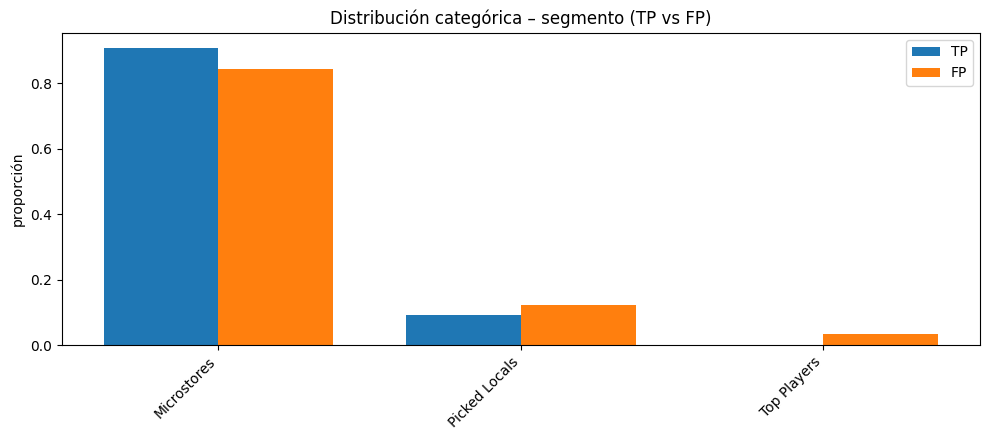

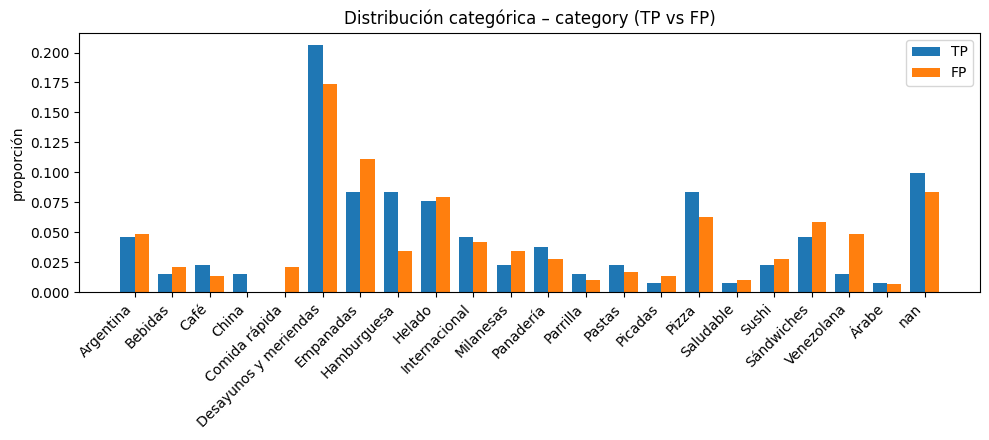

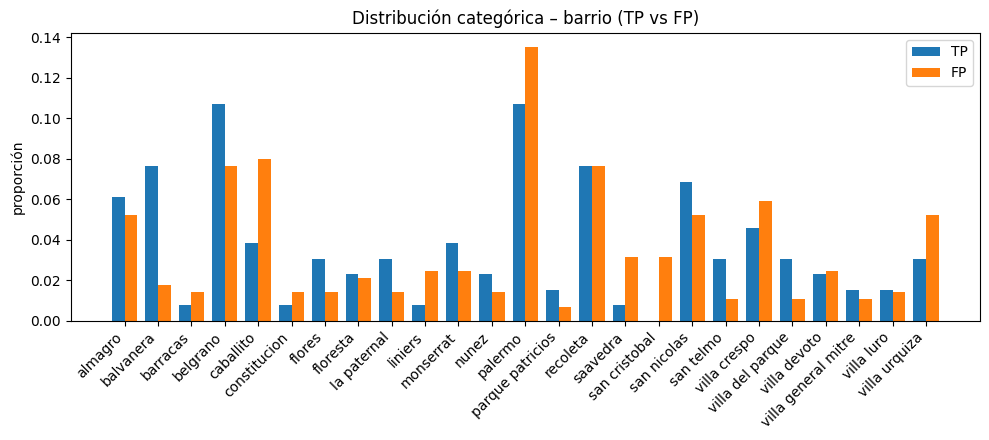

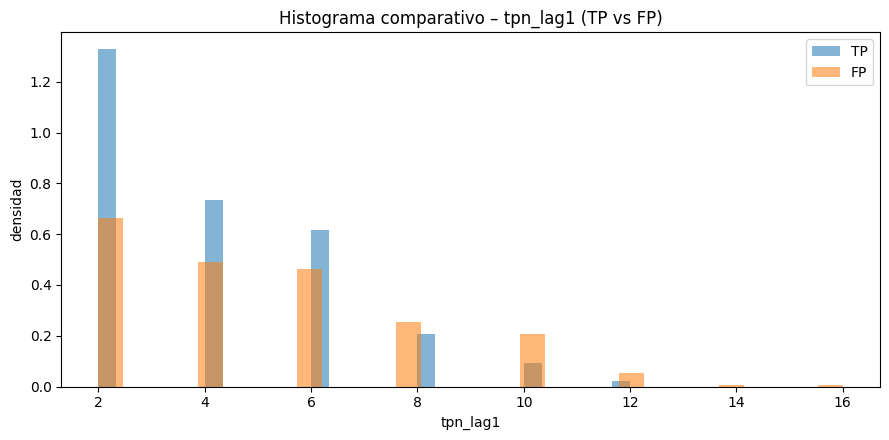

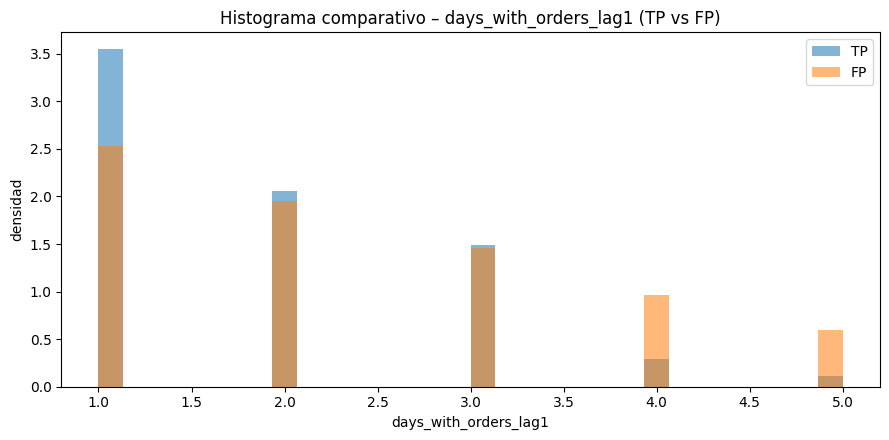

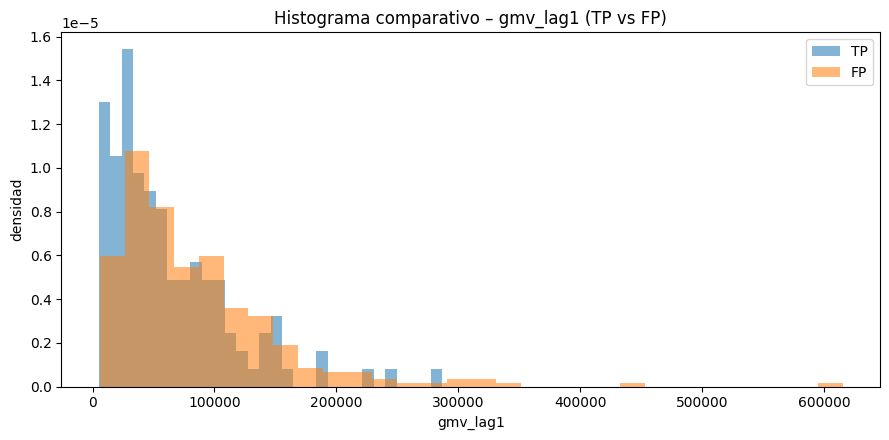

/tmp/ipykernel_3311/1943901792.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["TP", "FP"], showfliers=False)


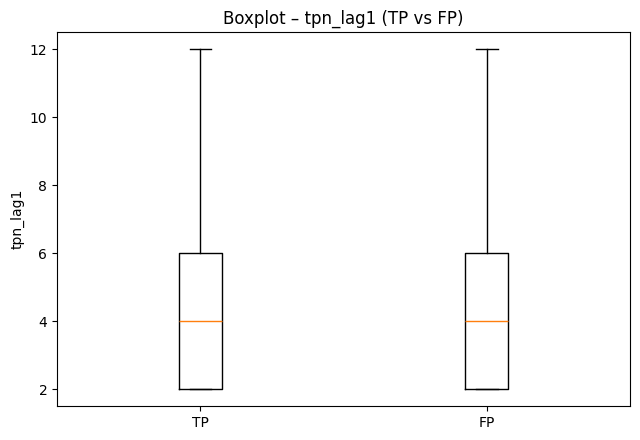

/tmp/ipykernel_3311/1943901792.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["TP", "FP"], showfliers=False)


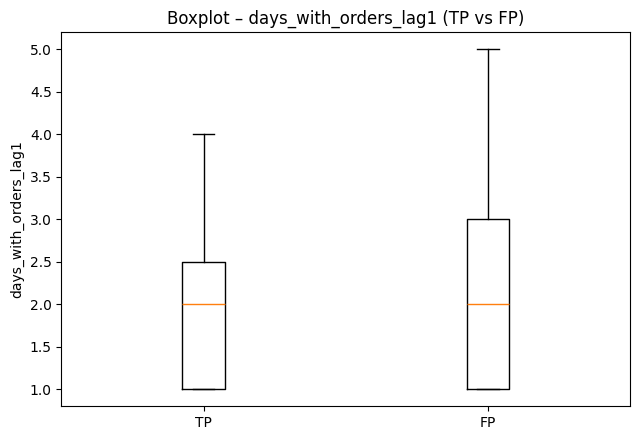

/tmp/ipykernel_3311/1943901792.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["TP", "FP"], showfliers=False)


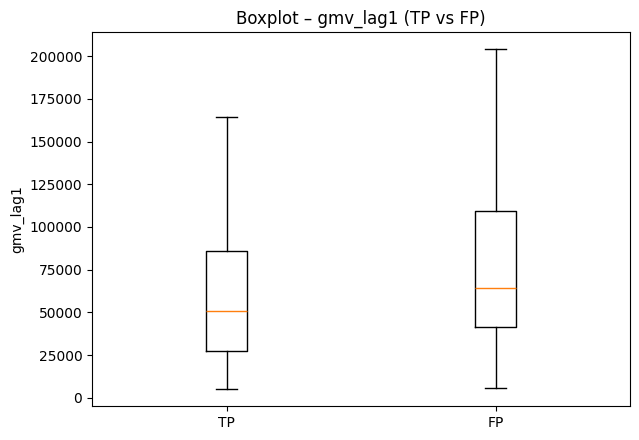

In [25]:
# ---- Particiones: TP y FP ----
tp = df_mes.loc[df_mes["case"]=="TP"].copy()
fp = df_mes.loc[df_mes["case"]=="FP"].copy()

CAT_COLS = ("segmento","category","barrio") 
NUM_COLS = ("tpn_lag1","days_with_orders_lag1","gmv_lag1", "churn_streak_lag1")

# =============== CATEGÓRICAS: barras comparativas (proporciones TP vs FP) ===============
def plot_cat_props(tp_df, fp_df, col, top_n=None, save=False):
    # proporciones
    p_tp = tp_df[col].value_counts(dropna=False, normalize=True)
    p_fp = fp_df[col].value_counts(dropna=False, normalize=True)
    idx = p_tp.index.union(p_fp.index)

    if top_n is not None:
        # ordenar por TP y tomar top_n (ajusta si preferís por total)
        idx = p_tp.sort_values(ascending=False).head(top_n).index.union(
              p_fp.sort_values(ascending=False).head(top_n).index)

    p_tp = p_tp.reindex(idx, fill_value=0.0)
    p_fp = p_fp.reindex(idx, fill_value=0.0)

    # plot
    x = np.arange(len(idx))
    w = 0.38
    plt.figure(figsize=(10, 4.5))
    plt.bar(x - w/2, p_tp.values, width=w, label="TP")
    plt.bar(x + w/2, p_fp.values, width=w, label="FP")
    plt.xticks(x, [str(v) for v in idx], rotation=45, ha="right")
    plt.ylabel("proporción")
    plt.title(f"Distribución categórica – {col} (TP vs FP)")
    plt.legend()
    plt.tight_layout()
    if save:
        plt.savefig(f"cat_{col}_TP_vs_FP.png", dpi=200)
    plt.show()

for c in CAT_COLS:
    if c in df_mes.columns:
        plot_cat_props(tp, fp, c, top_n=20, save=True)  # ajustá top_n si hay muchas categorías

# =============== NUMÉRICAS: histogramas comparativos (densidad) ===============
def plot_hist_tp_fp(tp_df, fp_df, col, bins=30, save=False):


    x_tp = tp_df[col].dropna().values
    x_fp = fp_df[col].dropna().values

    plt.figure(figsize=(9, 4.5))
    # bins especiales si la variable es discreta (enteros)
    if np.issubdtype(tp_df[col].dropna().dtype, np.integer) or col.endswith("streak"):
        xmin = int(min(x_tp.min() if len(x_tp) else 0, x_fp.min() if len(x_fp) else 0))
        xmax = int(max(x_tp.max() if len(x_tp) else 0, x_fp.max() if len(x_fp) else 0))
        bins = np.arange(xmin - 0.5, xmax + 1.5, 1)  # centra en enteros

    plt.hist(x_tp, bins=bins, alpha=0.55, density=True, label="TP")
    plt.hist(x_fp, bins=bins, alpha=0.55, density=True, label="FP")
    plt.xlabel(col)
    plt.ylabel("densidad")
    plt.title(f"Histograma comparativo – {col} (TP vs FP)")
    plt.legend()
    plt.tight_layout()
    if save:
        plt.savefig(f"num_{col}_hist_TP_vs_FP.png", dpi=200)
    plt.show()

for c in NUM_COLS:
    if c in df_mes.columns:
        plot_hist_tp_fp(tp, fp, c, bins=30, save=True)

# =============== NUMÉRICAS: boxplots lado a lado (opcional) ===============
def plot_box_tp_fp(tp_df, fp_df, col, save=False):
    data = [tp_df[col].dropna().values, fp_df[col].dropna().values]
    plt.figure(figsize=(6.5, 4.5))
    plt.boxplot(data, labels=["TP", "FP"], showfliers=False)
    plt.ylabel(col)
    plt.title(f"Boxplot – {col} (TP vs FP)")
    plt.tight_layout()
    if save:
        plt.savefig(f"num_{col}_box_TP_vs_FP.png", dpi=200)
    plt.show()

for c in NUM_COLS:
    if c in df_mes.columns:
        plot_box_tp_fp(tp, fp, c, save=True)


In [41]:
# === DIAGNÓSTICO DE df_mes ===
import pandas as pd

if "df_mes" not in globals():
    raise NameError("df_mes no existe en memoria. Ejecutá las celdas previas que lo crean.")

print(">> type(df_mes):", type(df_mes))
print(">> shape:", getattr(df_mes, 'shape', None))

print("\n>> COLUMNAS:")
print(list(df_mes.columns))

print("\n>> dtypes:")
print(df_mes.dtypes)

# Muestra 5 filas
print("\n>> HEAD(5):")
display(df_mes.head(5))

# ¿Qué valores tiene 'case'?
if "case" in df_mes.columns:
    print("\n>> value_counts(case):")
    print(df_mes["case"].astype(str).str.upper().value_counts())

# Intentar detectar columnas de ID y fecha presentes en df_mes
ID_CANDS   = ["store_id","store_id_anon","id","store","shop_id","brand_id"]
DATE_CANDS = ["period_month","period","fecha","date","ds","month","year"]

present_ids   = [c for c in ID_CANDS if c in df_mes.columns]
present_dates = [c for c in DATE_CANDS if c in df_mes.columns]

print("\n>> Posibles columnas de ID en df_mes:", present_ids)
print(">> Posibles columnas de FECHA en df_mes:", present_dates)



>> type(df_mes): <class 'pandas.core.frame.DataFrame'>
>> shape: (3751, 24)

>> COLUMNAS:
['segmento', 'barrio', 'category', 'tpn_lag1', 'gmv_lag1', 'gmv_lag2', 'days_with_orders_lag1', 'markdown_mean_lag1', 'markdown_mean_lag2', 'avg_shipping_cost_lag1', 'tpn_roll3_std', 'gmv_roll3_std', 'days_with_orders_roll3_mean', 'days_with_orders_roll3_std', 'markdown_mean_roll3_std', 'avg_shipping_cost_roll3_std', 'free_shipping_prop_roll3_mean', 'tpn_delta_1m', 'tpn_pctchg_1m', 'tpn_lag2_nanflag', 'y_true', 'y_pred', 'proba', 'case']

>> dtypes:
segmento                         category
barrio                           category
category                         category
tpn_lag1                          float64
gmv_lag1                          float64
gmv_lag2                          float64
days_with_orders_lag1             float64
markdown_mean_lag1                float64
markdown_mean_lag2                float64
avg_shipping_cost_lag1            float64
tpn_roll3_std                     fl

,segmento,barrio,category,tpn_lag1,gmv_lag1,gmv_lag2,days_with_orders_lag1,markdown_mean_lag1,markdown_mean_lag2,avg_shipping_cost_lag1,...,markdown_mean_roll3_std,avg_shipping_cost_roll3_std,free_shipping_prop_roll3_mean,tpn_delta_1m,tpn_pctchg_1m,tpn_lag2_nanflag,y_true,y_pred,proba,case
30,Microstores,balvanera,Parrilla,0.0,0.0,97200.0,0.0,0.000000,0.000000,0.000,...,0.000000,0.000000,0.000000,-2.0,-1.000000,0,0,0,0.017163,TN
44,Top Players,saavedra,Pollo,100.0,1476238.0,1238010.0,23.0,0.289618,0.175797,1137.664,...,0.124970,26.549935,0.799206,16.0,0.190476,0,0,0,0.030791,TN
68,Microstores,colegiales,Parrilla,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000,...,0.000000,0.000000,0.000000,0.0,0.000000,1,0,0,0.016816,TN
71,Top Players,barracas,Helado,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000,...,0.000000,0.000000,0.000000,0.0,0.000000,1,0,0,0.016612,TN
111,Picked Locals,san nicolas,Milanesas,8.0,259020.0,366080.0,4.0,0.132768,0.248894,1106.170,...,0.058263,34.500844,1.000000,-10.0,-0.555556,0,0,1,0.633867,FP



>> value_counts(case):
case
TN    3281
FP     288
TP     131
FN      51
Name: count, dtype: int64

>> Posibles columnas de ID en df_mes: []
>> Posibles columnas de FECHA en df_mes: []


In [45]:
import pandas as pd

if "Xy" not in globals() or not isinstance(Xy, pd.DataFrame):
    raise NameError("No encuentro `Xy` en memoria. Ejecutá las celdas donde se crea/carga `Xy` y volvé a correr.")

print(">> Xy shape:", Xy.shape)
print(">> columnas (primeras 40):", list(Xy.columns[:40]))

# Ver que tenga period_month y mirar 2025-08
if "period_month" not in Xy.columns:
    raise KeyError("`Xy` no tiene 'period_month'. Necesitamos esa columna para filtrar agosto 2025.")

mask_aug = Xy["period_month"].astype(str).str[:7].eq("2025-08")
print(">> filas en 2025-08:", int(mask_aug.sum()))
display(Xy.loc[mask_aug].head(5))

# Candidatas de columnas KPI
GMV_CANDS = ["gmv","GMV","gmv_mes","gmv_lc","gmv_lc_altered","gmv_current","GMV_total"]
MD_CANDS  = ["markdown_mean","markdown","md_mean","avg_markdown"]
CO_CANDS  = ["comision_actual","commission_rate","take_rate","commission","comision"]

GMV_COL = next((c for c in GMV_CANDS if c in Xy.columns), None)
MD_COL  = next((c for c in MD_CANDS  if c in Xy.columns), None)
CO_COL  = next((c for c in CO_CANDS  if c in Xy.columns), None)

print("\n>> Columnas KPI detectadas en Xy:")
print(" GMV :", GMV_COL)
print(" MD  :", MD_COL)
print(" COMM:", CO_COL)

if any(v is None for v in [GMV_COL, MD_COL, CO_COL]):
    raise KeyError("Falta al menos una columna para KPI (GMV/markdown/comisión) en `Xy`.")



>> Xy shape: (34223, 116)
>> columnas (primeras 40): ['store_id', 'period_month', 'churn_unique', 'segmento', 'barrio', 'category', 'tpn_lag1', 'tpn_lag2', 'tpn_lag3', 'gmv_lag1', 'gmv_lag2', 'gmv_lag3', 'days_with_orders_lag1', 'days_with_orders_lag2', 'days_with_orders_lag3', 'markdown_mean_lag1', 'markdown_mean_lag2', 'markdown_mean_lag3', 'avg_shipping_cost_lag1', 'avg_shipping_cost_lag2', 'avg_shipping_cost_lag3', 'free_shipping_prop_lag1', 'free_shipping_prop_lag2', 'free_shipping_prop_lag3', 'connectivity_lag1', 'connectivity_lag2', 'connectivity_lag3', 'total_min_open_lag1', 'total_min_open_lag2', 'total_min_open_lag3', 'total_minutes_all_lag1', 'total_minutes_all_lag2', 'total_minutes_all_lag3', 'churn_streak_lag1', 'churn_streak_lag2', 'churn_streak_lag3', 'tpn_roll3_mean', 'tpn_roll3_std', 'gmv_roll3_mean', 'gmv_roll3_std']
>> filas en 2025-08: 5293


,store_id,period_month,churn_unique,segmento,barrio,category,tpn_lag1,tpn_lag2,tpn_lag3,gmv_lag1,...,total_min_open_roll3_std_nanflag,total_minutes_all_roll3_mean_nanflag,total_minutes_all_roll3_std_nanflag,churn_streak_roll3_mean_nanflag,churn_streak_roll3_std_nanflag,tpn_delta_1m_nanflag,tpn_pctchg_1m_nanflag,open_rate_lag1_nanflag,churn_prev_nanflag,en_churn_streak_prev_nanflag
30,100006,2025-08-01,0.0,Microstores,balvanera,Parrilla,0.0,2.0,6.0,0.0,...,1,1,1,0,0,0,0,0,0,0
44,100007,2025-08-01,0.0,Top Players,saavedra,Pollo,100.0,84.0,42.0,1476238.0,...,0,0,0,0,0,0,0,0,0,0
56,100010,2025-08-01,NaN,Top Players,retiro,NaN,0.0,0.0,0.0,0.0,...,0,0,0,1,1,0,1,0,1,0
63,100020,2025-08-01,NaN,Microstores,palermo,Hamburguesa,0.0,0.0,0.0,0.0,...,1,1,1,1,1,1,1,0,1,0
68,100022,2025-08-01,0.0,Microstores,colegiales,Parrilla,0.0,0.0,0.0,0.0,...,1,1,1,1,1,1,1,0,1,0



>> Columnas KPI detectadas en Xy:
 GMV : None
 MD  : None
 COMM: None


KeyError: 'Falta al menos una columna para KPI (GMV/markdown/comisión) en `Xy`.'

In [47]:
import pandas as pd
import re

assert "Xy" in globals(), "`Xy` no está en memoria."
xy_aug = Xy[Xy["period_month"].astype(str).str[:7].eq("2025-08")].copy()
if xy_aug.empty:
    raise RuntimeError("`Xy` no tiene filas para 2025-08.")

def match_cols(cols, patterns):
    rx = re.compile("|".join(patterns), re.I)
    return [c for c in cols if rx.search(c)]

cols = list(Xy.columns)

gmv_cands = match_cols(cols, [r"\bgmv\b", r"\bgmv_"])
md_cands  = match_cols(cols, [r"markdown", r"\bmd_"])
co_cands  = match_cols(cols, [r"comision", r"commission", r"take_rate", r"\bcomm", r"take"])

def summarize(cand_list, label):
    rows = []
    for c in cand_list:
        is_lag = bool(re.search(r"lag", c, re.I))
        nn = int(xy_aug[c].notna().sum()) if c in xy_aug.columns else 0
        rows.append({"col": c, "is_lag": is_lag, "notnull_in_2025_08": nn})
    df = pd.DataFrame(rows).sort_values(["is_lag","notnull_in_2025_08"], ascending=[True, False])
    print(f"\n>> {label} candidatas (orden: no-lag primero, mayor cobertura en 2025-08):")
    display(df)
    return df

gmv_df = summarize(gmv_cands, "GMV")
md_df  = summarize(md_cands,  "Markdown")
co_df  = summarize(co_cands,  "Comisión")

print("\nSi ves columnas 'sin lag' con buena cobertura (notnull_in_2025_08 alto), usaremos esas.")




>> GMV candidatas (orden: no-lag primero, mayor cobertura en 2025-08):


,col,is_lag,notnull_in_2025_08
3,gmv_roll3_mean,False,5293
4,gmv_roll3_std,False,5293
0,gmv_lag1,True,5293
1,gmv_lag2,True,5293
2,gmv_lag3,True,5293
5,gmv_lag1_nanflag,True,5293
6,gmv_lag2_nanflag,True,5293
7,gmv_lag3_nanflag,True,5293
8,gmv_roll3_mean_nanflag,True,5293
9,gmv_roll3_std_nanflag,True,5293



>> Markdown candidatas (orden: no-lag primero, mayor cobertura en 2025-08):


,col,is_lag,notnull_in_2025_08
3,markdown_mean_roll3_mean,False,5293
4,markdown_mean_roll3_std,False,5293
0,markdown_mean_lag1,True,5293
1,markdown_mean_lag2,True,5293
2,markdown_mean_lag3,True,5293
5,markdown_mean_lag1_nanflag,True,5293
6,markdown_mean_lag2_nanflag,True,5293
7,markdown_mean_lag3_nanflag,True,5293
8,markdown_mean_roll3_mean_nanflag,True,5293
9,markdown_mean_roll3_std_nanflag,True,5293


KeyError: 'is_lag'

In [50]:
# === Agregar comisión a TP y FN del TEST y calcular KPI (agosto-2025) ===
import builtins
import pandas as pd
import numpy as np

# 0) tomar objetos desde el global real
g = builtins.globals()
df_mes = g["df_mes"]
Xy     = g["Xy"]

# 1) índices TP / FN del test (en df_mes)
case_up = df_mes["case"].astype(str).str.upper()
tp_idx  = df_mes.index[case_up.eq("TP")]
fn_idx  = df_mes.index[case_up.eq("FN")]

# 2) mapear esos índices a store_id usando Xy (mismo índice que df_mes)
xy_aug = Xy[Xy["period_month"].astype(str).str[:7].eq("2025-08")]
tp_sid = xy_aug.loc[xy_aug.index.intersection(tp_idx), "store_id"]
fn_sid = xy_aug.loc[xy_aug.index.intersection(fn_idx), "store_id"]

# 3) detectar la base original con comisión (gmv + markdown_mean + comision_actual)
BASE = None
for name, obj in list(g.items()):
    if isinstance(obj, pd.DataFrame) and {"store_id","period_month","gmv","markdown_mean","comision_actual"}.issubset(obj.columns):
        # aseguramos que tenga agosto
        if obj["period_month"].astype(str).str[:7].eq("2025-08").any():
            BASE = obj
            break
if BASE is None:
    raise RuntimeError("No encontré la base original con gmv/markdown_mean/comision_actual y period_month.")

# 4) construir un mapa de comisión por store_id (valor 'actual' no nulo; si hay varios, tomamos el último conocido)
base_comm = BASE[["store_id","period_month","comision_actual"]].copy()
# normalizar a num y [0,1]
base_comm["comision_actual"] = pd.to_numeric(base_comm["comision_actual"], errors="coerce")
if base_comm["comision_actual"].dropna().gt(1).any():
    base_comm["comision_actual"] /= 100.0
base_comm["comision_actual"] = base_comm["comision_actual"].clip(0,1)

# quedarnos con la última comisión disponible por store_id (ordenando por period_month)
base_comm["_period_key"] = base_comm["period_month"].astype(str)
comm_map = (base_comm.sort_values(["store_id","_period_key"])
                     .dropna(subset=["comision_actual"])
                     .groupby("store_id", as_index=True)["comision_actual"]
                     .last())

# 5) inyectar comisión a df_mes SOLO en TP y FN (nueva columna para no pisar nada)
df_mes = df_mes.copy()
df_mes["comision_from_base"] = np.nan

# asignar según store_id mapeado desde Xy
df_mes.loc[tp_sid.index, "comision_from_base"] = comm_map.reindex(tp_sid.values).values
df_mes.loc[fn_sid.index, "comision_from_base"] = comm_map.reindex(fn_sid.values).values

# 6) sanitizar inputs del KPI en df_mes
for c in ["gmv_lag1","markdown_mean_lag1"]:
    if c not in df_mes.columns:
        raise KeyError(f"Falta '{c}' en df_mes")
df_mes["gmv_lag1"] = pd.to_numeric(df_mes["gmv_lag1"], errors="coerce").fillna(0)

df_mes["markdown_mean_lag1"] = pd.to_numeric(df_mes["markdown_mean_lag1"], errors="coerce")
# manejar casos negativos mínimos tipo -0.000263 y llevar a [0,1]
df_mes["markdown_mean_lag1"] = df_mes["markdown_mean_lag1"].clip(lower=0, upper=1).fillna(0)

# comisión: si quedó fuera de rango por algún registro raro, traer a [0,1] y nulos->0
df_mes["comision_from_base"] = pd.to_numeric(df_mes["comision_from_base"], errors="coerce").clip(0,1).fillna(0)

# 7) KPI: ingresos = gmv_lag1 * (1 - markdown_mean_lag1) * comision_from_base
tp = df_mes.loc[tp_idx].copy()
fn = df_mes.loc[fn_idx].copy()

ing_TP = float((tp["gmv_lag1"] * (1 - tp["markdown_mean_lag1"]) * tp["comision_from_base"]).sum())
ing_FN = float((fn["gmv_lag1"] * (1 - fn["markdown_mean_lag1"]) * fn["comision_from_base"]).sum())

print("=== KPI agosto-2025 (inyectando comisión desde base original) ===")
print(f"Ingresos totales TP: {ing_TP:,.2f}")
print(f"Ingresos totales FN: {ing_FN:,.2f}")

# opcional: mostrar cuántos TP/FN quedaron con comisión=0 por falta de dato
print("\nCobertura de comisión en TP/FN:")
print(" TP con comisión > 0:", int((tp["comision_from_base"]>0).sum()), "/", tp.shape[0])
print(" FN con comisión > 0:", int((fn["comision_from_base"]>0).sum()), "/", fn.shape[0])




=== KPI agosto-2025 (inyectando comisión desde base original) ===
Ingresos totales TP: 3,143,247.68
Ingresos totales FN: 10,829,630.84

Cobertura de comisión en TP/FN:
 TP con comisión > 0: 129 / 131
 FN con comisión > 0: 47 / 51


In [51]:
# === Auditoría TP vs FN: ¿por qué FN suma más ingresos con menos casos? ===
import pandas as pd
import numpy as np

# Precondiciones
assert "df_mes" in globals(), "df_mes no está en memoria"
assert "Xy" in globals(), "Xy no está en memoria"
for c in ["gmv_lag1","markdown_mean_lag1","comision_from_base","case"]:
    if c not in df_mes.columns:
        raise KeyError(f"Falta columna en df_mes: {c}")

# Asegurar rangos y calcular ingreso por fila
aud = df_mes.copy()
aud["gmv_lag1"] = pd.to_numeric(aud["gmv_lag1"], errors="coerce").fillna(0)
aud["markdown_mean_lag1"] = pd.to_numeric(aud["markdown_mean_lag1"], errors="coerce").fillna(0).clip(0,1)
aud["comision_from_base"] = pd.to_numeric(aud["comision_from_base"], errors="coerce").fillna(0).clip(0,1)

aud["ingreso_row"] = aud["gmv_lag1"] * (1 - aud["markdown_mean_lag1"]) * aud["comision_from_base"]
aud["caseU"] = aud["case"].astype(str).str.upper()

# Mapear store_id (para listar top contribuyentes)
xy_aug = Xy[Xy["period_month"].astype(str).str[:7].eq("2025-08")]
sid_map = xy_aug["store_id"]

# Resumen agregados TP vs FN
def pct(s, q): 
    return float(np.nanpercentile(s.values, q)) if len(s)>0 else np.nan

def summarize(group_df):
    return pd.Series({
        "n": group_df.shape[0],
        "ingreso_total": float(group_df["ingreso_row"].sum()),
        "ingreso_mediano": pct(group_df["ingreso_row"], 50),
        "ingreso_p75": pct(group_df["ingreso_row"], 75),
        "ingreso_p90": pct(group_df["ingreso_row"], 90),
        "gmv_lag1_prom": float(group_df["gmv_lag1"].mean()),
        "gmv_lag1_med": pct(group_df["gmv_lag1"], 50),
        "markdown_prom": float(group_df["markdown_mean_lag1"].mean()),
        "comision_prom": float(group_df["comision_from_base"].mean()),
        "con_comision>0": int((group_df["comision_from_base"]>0).sum())
    })

resumen = aud.loc[aud["caseU"].isin(["TP","FN"])].groupby("caseU").apply(summarize).T
print("=== Resumen TP vs FN (agosto-2025; usando gmv_lag1, markdown_lag1 y comisión inyectada) ===")
display(resumen)

# Top contribuyentes por grupo (para ver outliers que explican el total)
def top_contrib(group_label, k=10):
    g = aud.loc[aud["caseU"].eq(group_label), 
                ["ingreso_row","gmv_lag1","markdown_mean_lag1","comision_from_base"]].copy()
    # anexar store_id por índice (si existe en xy_aug)
    g["store_id"] = sid_map.reindex(g.index)
    g = g.sort_values("ingreso_row", ascending=False).head(k)
    print(f"\nTop {k} contribuyentes — {group_label}")
    display(g)

top_contrib("TP", 10)
top_contrib("FN", 10)


=== Resumen TP vs FN (agosto-2025; usando gmv_lag1, markdown_lag1 y comisión inyectada) ===


/tmp/ipykernel_3311/613645818.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = aud.loc[aud["caseU"].isin(["TP","FN"])].groupby("caseU").apply(summarize).T


caseU,FN,TP
n,5.100000e+01,1.310000e+02
ingreso_total,1.082963e+07,3.143248e+06
ingreso_mediano,1.024515e+05,1.713684e+04
ingreso_p75,2.943208e+05,3.267600e+04
ingreso_p90,5.865120e+05,5.118523e+04
gmv_lag1_prom,8.222940e+05,6.286295e+04
gmv_lag1_med,3.749500e+05,5.072800e+04
markdown_prom,6.556758e-02,3.278121e-02
comision_prom,3.517647e-01,3.958397e-01
con_comision>0,4.700000e+01,1.290000e+02



Top 10 contribuyentes — TP


,ingreso_row,gmv_lag1,markdown_mean_lag1,comision_from_base,store_id
180,120539.9748,286999.94,0.0,0.420,100042
77360,94920.0000,226000.00,0.0,0.420,113759
70695,71175.0000,189800.00,0.0,0.375,112669
58317,69336.0000,192600.00,0.0,0.360,110486
40794,65184.0000,155200.00,0.0,0.420,107267
66944,64800.0000,240000.00,0.0,0.270,111992
43979,62932.8000,149840.00,0.0,0.420,107832
74160,62160.0000,148000.00,0.0,0.420,113231
73858,59220.0000,141000.00,0.0,0.420,113184
66773,57019.2000,135760.00,0.0,0.420,111960



Top 10 contribuyentes — FN


,ingreso_row,gmv_lag1,markdown_mean_lag1,comision_from_base,store_id
73554,1.167487e+06,3574640.00,0.092771,0.36,113128
9352,8.418558e+05,2033898.00,0.014494,0.42,101679
1243,7.641900e+05,2547300.00,0.000000,0.30,100236
31801,7.019040e+05,1671200.00,0.000000,0.42,105622
63872,6.446707e+05,1554600.00,0.012653,0.42,111455
74544,5.865120e+05,1629200.00,0.000000,0.36,113304
60263,4.131960e+05,983800.00,0.000000,0.42,110805
72749,3.676941e+05,964774.52,0.092573,0.42,113006
19199,3.553200e+05,846000.00,0.000000,0.42,103451
73776,3.378270e+05,804350.00,0.000000,0.42,113175


In [52]:
# === Comparación de KPI: Baseline (lag1) vs Real Agosto ===
import pandas as pd
import numpy as np
import builtins

g = builtins.globals()
df_mes = g["df_mes"]
Xy     = g["Xy"]

# (1) Índices TP/FN
caseU = df_mes["case"].astype(str).str.upper()
tp_idx = df_mes.index[caseU.eq("TP")]
fn_idx = df_mes.index[caseU.eq("FN")]

# (2) Comisión ya inyectada (de tu celda anterior)
assert "comision_from_base" in df_mes.columns, "Falta 'comision_from_base' (inyectala con la celda anterior)."

# ---------- DEF A: Baseline con lag1 (lo que venías usando) ----------
A_tp = (df_mes.loc[tp_idx, "gmv_lag1"] * (1 - df_mes.loc[tp_idx, "markdown_mean_lag1"].clip(0,1)) 
        * df_mes.loc[tp_idx, "comision_from_base"]).sum()
A_fn = (df_mes.loc[fn_idx, "gmv_lag1"] * (1 - df_mes.loc[fn_idx, "markdown_mean_lag1"].clip(0,1)) 
        * df_mes.loc[fn_idx, "comision_from_base"]).sum()

# ---------- DEF B: Real de agosto desde base original ----------
# mapear store_id + periodo para agosto
xy_aug = Xy[Xy["period_month"].astype(str).str[:7].eq("2025-08")][["store_id","period_month"]].copy()
xy_aug["period_key"] = xy_aug["period_month"].astype(str).str[:7]

# localizar la base original con gmv / markdown_mean / comision_actual (ya la detectaste antes)
BASE = None
for name, obj in list(g.items()):
    if isinstance(obj, pd.DataFrame) and {"store_id","period_month","gmv","markdown_mean","comision_actual"}.issubset(obj.columns):
        if obj["period_month"].astype(str).str[:7].eq("2025-08").any():
            BASE = obj.copy(); break
assert BASE is not None, "No encuentro la base original."

base_aug = BASE[BASE["period_month"].astype(str).str[:7].eq("2025-08")].copy()
base_aug["period_key"] = base_aug["period_month"].astype(str).str[:7]

# normalizar valores
for c in ["gmv","markdown_mean","comision_actual"]:
    base_aug[c] = pd.to_numeric(base_aug[c], errors="coerce")
if base_aug["markdown_mean"].dropna().gt(1).any(): base_aug["markdown_mean"] /= 100.0
if base_aug["comision_actual"].dropna().gt(1).any(): base_aug["comision_actual"] /= 100.0
base_aug["markdown_mean"]   = base_aug["markdown_mean"].clip(0,1).fillna(0)
base_aug["comision_actual"] = base_aug["comision_actual"].clip(0,1).fillna(0)
base_aug["gmv"] = base_aug["gmv"].fillna(0)

# índices comunes para TP/FN -> store_id
tp_sid = xy_aug.loc[xy_aug.index.intersection(tp_idx), ["store_id","period_key"]]
fn_sid = xy_aug.loc[xy_aug.index.intersection(fn_idx), ["store_id","period_key"]]

B_tp_df = tp_sid.merge(base_aug[["store_id","period_key","gmv","markdown_mean","comision_actual"]],
                       on=["store_id","period_key"], how="left")
B_fn_df = fn_sid.merge(base_aug[["store_id","period_key","gmv","markdown_mean","comision_actual"]],
                       on=["store_id","period_key"], how="left")

B_tp = float((B_tp_df["gmv"] * (1 - B_tp_df["markdown_mean"]) * B_tp_df["comision_actual"]).sum())
B_fn = float((B_fn_df["gmv"] * (1 - B_fn_df["markdown_mean"]) * B_fn_df["comision_actual"]).sum())

# ---------- Mostrar ----------
print("=== KPI — Comparación definiciones (Agosto 2025) ===")
print(f"Def A (baseline con lag1)  -> TP: {A_tp:,.2f} | FN: {A_fn:,.2f}")
print(f"Def B (real mes de agosto) -> TP: {B_tp:,.2f} | FN: {B_fn:,.2f}")

# Mini-resumen para explicar la diferencia
def med(x): return float(np.nanmedian(x)) if len(x)>0 else np.nan
gmv_tp_med = med(df_mes.loc[tp_idx, "gmv_lag1"]); gmv_fn_med = med(df_mes.loc[fn_idx, "gmv_lag1"])
print("\nMediana GMV_lag1 — TP vs FN:", f"{gmv_tp_med:,.0f}", "vs", f"{gmv_fn_med:,.0f}")


=== KPI — Comparación definiciones (Agosto 2025) ===
Def A (baseline con lag1)  -> TP: 3,143,247.68 | FN: 10,829,630.84
Def B (real mes de agosto) -> TP: 0.00 | FN: 0.00

Mediana GMV_lag1 — TP vs FN: 50,728 vs 374,950


In [53]:
# === KPI TP/FN (Agosto 2025) — Resumen final con ambas definiciones ===
import builtins, pandas as pd, numpy as np

g = builtins.globals()
df_mes = g["df_mes"]; Xy = g["Xy"]

# Índices TP/FN desde df_mes
case = df_mes["case"].astype(str).str.upper()
tp_idx = df_mes.index[case.eq("TP")]
fn_idx = df_mes.index[case.eq("FN")]

# Asegurar comisión inyectada (col creada antes)
if "comision_from_base" not in df_mes.columns:
    raise KeyError("Falta 'comision_from_base'. Corré la celda que inyecta comisión desde la base original.")

# -------- Def A (baseline con lag1) --------
defA_TP = float((df_mes.loc[tp_idx, "gmv_lag1"] * (1 - df_mes.loc[tp_idx, "markdown_mean_lag1"].clip(0,1)) * df_mes.loc[tp_idx, "comision_from_base"]).sum())
defA_FN = float((df_mes.loc[fn_idx, "gmv_lag1"] * (1 - df_mes.loc[fn_idx, "markdown_mean_lag1"].clip(0,1)) * df_mes.loc[fn_idx, "comision_from_base"]).sum())

# -------- Def B (real agosto) con base original --------
# localizar base original con gmv / markdown_mean / comision_actual
BASE = None
for name, obj in list(g.items()):
    if isinstance(obj, pd.DataFrame) and {"store_id","period_month","gmv","markdown_mean","comision_actual"}.issubset(obj.columns):
        if obj["period_month"].astype(str).str[:7].eq("2025-08").any():
            BASE = obj.copy(); break
if BASE is None:
    raise RuntimeError("No encuentro la base original con gmv/markdown_mean/comision_actual para 2025-08.")

base_aug = BASE[BASE["period_month"].astype(str).str[:7].eq("2025-08")].copy()
for c in ["gmv","markdown_mean","comision_actual"]:
    base_aug[c] = pd.to_numeric(base_aug[c], errors="coerce")
if base_aug["markdown_mean"].dropna().gt(1).any(): base_aug["markdown_mean"] /= 100.0
if base_aug["comision_actual"].dropna().gt(1).any(): base_aug["comision_actual"] /= 100.0
base_aug["markdown_mean"]   = base_aug["markdown_mean"].clip(0,1).fillna(0)
base_aug["comision_actual"] = base_aug["comision_actual"].clip(0,1).fillna(0)
base_aug["period_key"] = base_aug["period_month"].astype(str).str[:7]
xy_aug = Xy[Xy["period_month"].astype(str).str[:7].eq("2025-08")][["store_id","period_month"]].copy()
xy_aug["period_key"] = xy_aug["period_month"].astype(str).str[:7]

tp_sid = xy_aug.loc[xy_aug.index.intersection(tp_idx), ["store_id","period_key"]]
fn_sid = xy_aug.loc[xy_aug.index.intersection(fn_idx), ["store_id","period_key"]]

B_tp_df = tp_sid.merge(base_aug[["store_id","period_key","gmv","markdown_mean","comision_actual"]], on=["store_id","period_key"], how="left")
B_fn_df = fn_sid.merge(base_aug[["store_id","period_key","gmv","markdown_mean","comision_actual"]], on=["store_id","period_key"], how="left")

defB_TP = float((B_tp_df["gmv"] * (1 - B_tp_df["markdown_mean"]) * B_tp_df["comision_actual"]).sum())
defB_FN = float((B_fn_df["gmv"] * (1 - B_fn_df["markdown_mean"]) * B_fn_df["comision_actual"]).sum())

# Métricas explicativas
def p50(x): return float(np.nanmedian(pd.to_numeric(x, errors="coerce")))
gmv_med_TP = p50(df_mes.loc[tp_idx, "gmv_lag1"])
gmv_med_FN = p50(df_mes.loc[fn_idx, "gmv_lag1"])

res = pd.DataFrame({
    "casos": [len(tp_idx), len(fn_idx)],
    "KPI_def_A_lag1": [defA_TP, defA_FN],
    "KPI_def_B_agosto": [defB_TP, defB_FN],
    "gmv_lag1_mediana": [gmv_med_TP, gmv_med_FN]
}, index=["TP","FN"])

print("=== KPI TP/FN — Agosto 2025 ===")
display(res.style.format({"KPI_def_A_lag1": "{:,.2f}", "KPI_def_B_agosto": "{:,.2f}", "gmv_lag1_mediana": "{:,.0f}"}))


=== KPI TP/FN — Agosto 2025 ===


,casos,KPI_def_A_lag1,KPI_def_B_agosto,gmv_lag1_mediana
TP,131,"3,143,247.68",0.00,"50,728"
FN,51,"10,829,630.84",0.00,"374,950"


In [54]:
# === BLOQUE FINAL — KPI TP/FN (Agosto 2025) ===
# Deja ambos KPIs (A=lag1, B=real agosto) y fija cuál reportar.
# Requiere: df_mes con 'case', 'gmv_lag1', 'markdown_mean_lag1', 'comision_from_base' ya calculada;
#           Xy con 'store_id','period_month';
#           Base original con 'store_id','period_month','gmv','markdown_mean','comision_actual' (para Def B).

import builtins, pandas as pd, numpy as np
g = builtins.globals()

# ----------------- Configuración: elegí "A" (lag1) o "B" (real agosto) -----------------
KPI_OFICIAL = "A"   # cambia a "B" si querés reportar valores efectivos de agosto

# ----------------- Índices TP/FN desde df_mes -----------------
df_mes = g["df_mes"]; Xy = g["Xy"]
case = df_mes["case"].astype(str).str.upper()
tp_idx = df_mes.index[case.eq("TP")]
fn_idx = df_mes.index[case.eq("FN")]

# ----------------- Def A (lag1) -----------------
if "comision_from_base" not in df_mes.columns:
    raise KeyError("Falta 'comision_from_base'. Corré la celda que inyecta comisión desde la base original.")

defA_TP = float((df_mes.loc[tp_idx, "gmv_lag1"] * (1 - df_mes.loc[tp_idx, "markdown_mean_lag1"].clip(0,1)) * df_mes.loc[tp_idx, "comision_from_base"]).sum())
defA_FN = float((df_mes.loc[fn_idx, "gmv_lag1"] * (1 - df_mes.loc[fn_idx, "markdown_mean_lag1"].clip(0,1)) * df_mes.loc[fn_idx, "comision_from_base"]).sum())

# ----------------- Def B (real agosto) -----------------
# Detectar base original (si no la tenés ya en una variable)
BASE = None
for name, obj in list(g.items()):
    if isinstance(obj, pd.DataFrame) and {"store_id","period_month","gmv","markdown_mean","comision_actual"}.issubset(obj.columns):
        if obj["period_month"].astype(str).str[:7].eq("2025-08").any():
            BASE = obj.copy(); break
if BASE is None:
    raise RuntimeError("No encuentro la base original con gmv/markdown_mean/comision_actual para 2025-08.")

base_aug = BASE[BASE["period_month"].astype(str).str[:7].eq("2025-08")].copy()
for c in ["gmv","markdown_mean","comision_actual"]:
    base_aug[c] = pd.to_numeric(base_aug[c], errors="coerce")
if base_aug["markdown_mean"].dropna().gt(1).any(): base_aug["markdown_mean"] /= 100.0
if base_aug["comision_actual"].dropna().gt(1).any(): base_aug["comision_actual"] /= 100.0
base_aug["markdown_mean"]   = base_aug["markdown_mean"].clip(0,1).fillna(0)
base_aug["comision_actual"] = base_aug["comision_actual"].clip(0,1).fillna(0)
base_aug["period_key"] = base_aug["period_month"].astype(str).str[:7]

xy_aug = Xy[Xy["period_month"].astype(str).str[:7].eq("2025-08")][["store_id","period_month"]].copy()
xy_aug["period_key"] = xy_aug["period_month"].astype(str).str[:7]

tp_sid = xy_aug.loc[xy_aug.index.intersection(tp_idx), ["store_id","period_key"]]
fn_sid = xy_aug.loc[xy_aug.index.intersection(fn_idx), ["store_id","period_key"]]

B_tp_df = tp_sid.merge(base_aug[["store_id","period_key","gmv","markdown_mean","comision_actual"]], on=["store_id","period_key"], how="left")
B_fn_df = fn_sid.merge(base_aug[["store_id","period_key","gmv","markdown_mean","comision_actual"]], on=["store_id","period_key"], how="left")

defB_TP = float((B_tp_df["gmv"] * (1 - B_tp_df["markdown_mean"]) * B_tp_df["comision_actual"]).sum())
defB_FN = float((B_fn_df["gmv"] * (1 - B_fn_df["markdown_mean"]) * B_fn_df["comision_actual"]).sum())

# ----------------- Elegir KPI oficial y exponer variables limpias -----------------
if KPI_OFICIAL.upper() == "A":
    KPI_TP = defA_TP
    KPI_FN = defA_FN
    KPI_DEF = "A (baseline con lag1)"
else:
    KPI_TP = defB_TP
    KPI_FN = defB_FN
    KPI_DEF = "B (valores reales de agosto)"

resumen = pd.DataFrame({
    "casos": [len(tp_idx), len(fn_idx)],
    "KPI_def_A_lag1": [defA_TP, defA_FN],
    "KPI_def_B_agosto": [defB_TP, defB_FN],
    "KPI_oficial": [KPI_TP if KPI_OFICIAL.upper()=="A" else defB_TP,
                    KPI_FN if KPI_OFICIAL.upper()=="A" else defB_FN],
}, index=["TP","FN"])

print(f"=== KPI TP/FN — Agosto 2025 (definición oficial: {KPI_DEF}) ===")
display(resumen.style.format("{:,.2f}"))

# Variables finales para usar en el resto de la notebook/reportes:
kpi_tp_total = KPI_TP
kpi_fn_total = KPI_FN

# (Opcional) guardar CSV
# resumen.to_csv("kpi_tp_fn_agosto2025.csv", index=True)


=== KPI TP/FN — Agosto 2025 (definición oficial: A (baseline con lag1)) ===


,casos,KPI_def_A_lag1,KPI_def_B_agosto,KPI_oficial
TP,131.00,"3,143,247.68",0.00,"3,143,247.68"
FN,51.00,"10,829,630.84",0.00,"10,829,630.84"


In [55]:
print("Cobertura comisión — TP:", (df_mes.loc[df_mes.case.str.upper()=="TP","comision_from_base"]>0).mean())
print("Cobertura comisión — FN:", (df_mes.loc[df_mes.case.str.upper()=="FN","comision_from_base"]>0).mean())


Cobertura comisión — TP: 0.9847328244274809
Cobertura comisión — FN: 0.9215686274509803


In [63]:
# --- Prep: elegir columna de comisión, sanear y calcular ingreso por fila (DEF A) ---
import pandas as pd
import numpy as np

assert "df_mes" in globals(), "df_mes no está en memoria"

dfA = df_mes.copy()
dfA["caseU"] = dfA["case"].astype(str).str.upper()

# Usar comisión final si existe; si no, la inyectada
COMM_COL = "comision_final_kpi" if "comision_final_kpi" in dfA.columns else "comision_from_base"
if COMM_COL not in dfA.columns:
    raise KeyError("Falta 'comision_final_kpi' o 'comision_from_base' en df_mes.")

for c in ["gmv_lag1", "markdown_mean_lag1", COMM_COL]:
    dfA[c] = pd.to_numeric(dfA[c], errors="coerce").fillna(0)
dfA["markdown_mean_lag1"] = dfA["markdown_mean_lag1"].clip(0, 1)
dfA[COMM_COL] = dfA[COMM_COL].clip(0, 1)

# Ingreso por fila (DEF A)
dfA["ingreso_row_A"] = dfA["gmv_lag1"] * (1 - dfA["markdown_mean_lag1"]) * dfA[COMM_COL]

kpi_A_TP = float(dfA.loc[dfA["caseU"].eq("TP"), "ingreso_row_A"].sum())
kpi_A_FN = float(dfA.loc[dfA["caseU"].eq("FN"), "ingreso_row_A"].sum())
kpi_A_TP, kpi_A_FN



(3143247.6841602935, 10829630.842299666)

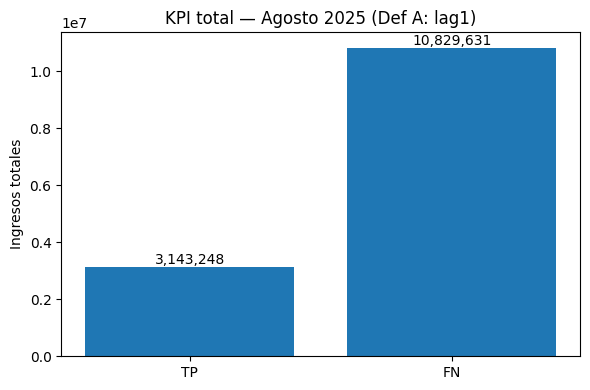

In [64]:
import matplotlib.pyplot as plt

labels = ["TP","FN"]
values = [kpi_A_TP, kpi_A_FN]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.title("KPI total — Agosto 2025 (Def A: lag1)")
plt.ylabel("Ingresos totales")
for i, v in enumerate(values):
    plt.text(i, v, f"{v:,.0f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("A_kpi_total_TP_vs_FN.png", dpi=200)
plt.show()



/tmp/ipykernel_3311/466100126.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([tp_vals, fn_vals], labels=["TP","FN"], showfliers=False)


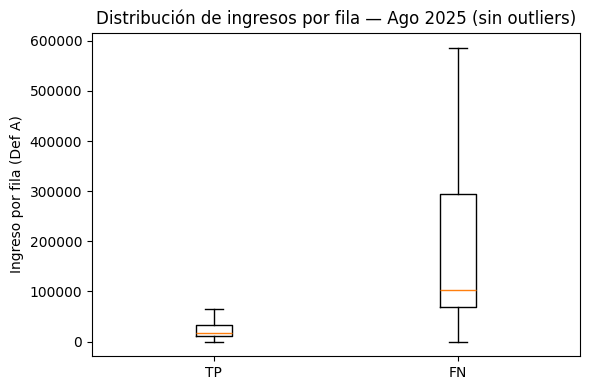

In [65]:
import matplotlib.pyplot as plt

tp_vals = dfA.loc[dfA["caseU"].eq("TP"), "ingreso_row_A"].values
fn_vals = dfA.loc[dfA["caseU"].eq("FN"), "ingreso_row_A"].values

plt.figure(figsize=(6,4))
plt.boxplot([tp_vals, fn_vals], labels=["TP","FN"], showfliers=False)
plt.ylabel("Ingreso por fila (Def A)")
plt.title("Distribución de ingresos por fila — Ago 2025 (sin outliers)")
plt.tight_layout()
plt.savefig("A_box_ingreso_por_fila_TP_vs_FN.png", dpi=200)
plt.show()


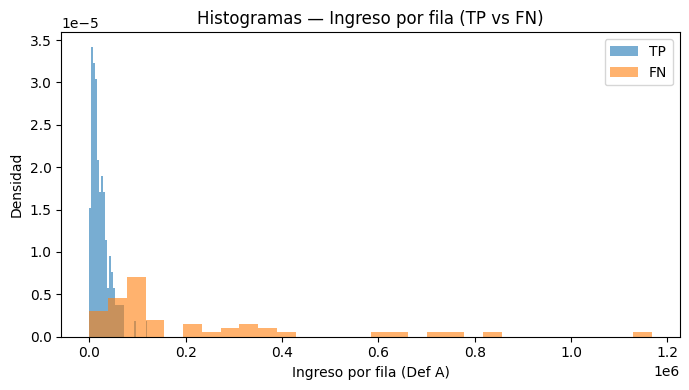

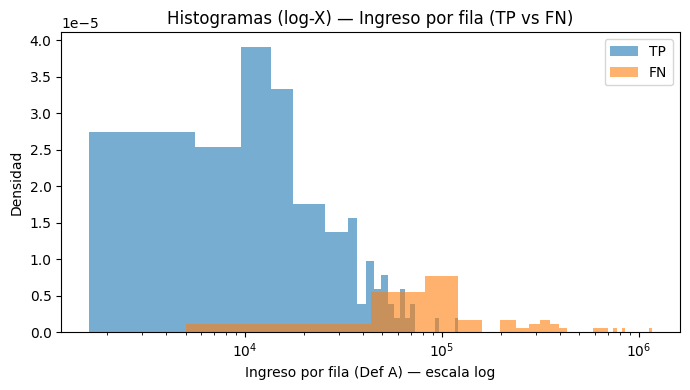

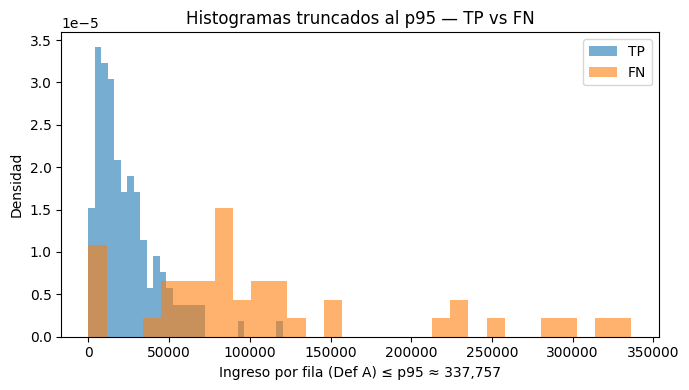

In [66]:
import numpy as np
import matplotlib.pyplot as plt

tp_vals = dfA.loc[dfA["caseU"].eq("TP"), "ingreso_row_A"].values
fn_vals = dfA.loc[dfA["caseU"].eq("FN"), "ingreso_row_A"].values

# (a) Escala lineal (puede quedar “aplastado” por outliers de FN)
plt.figure(figsize=(7,4))
plt.hist(tp_vals, bins=30, alpha=0.6, density=True, label="TP")
plt.hist(fn_vals, bins=30, alpha=0.6, density=True, label="FN")
plt.xlabel("Ingreso por fila (Def A)")
plt.ylabel("Densidad")
plt.title("Histogramas — Ingreso por fila (TP vs FN)")
plt.legend()
plt.tight_layout()
plt.savefig("A_hist_ingreso_lineal.png", dpi=200)
plt.show()

# (b) Escala log en X (mejor para ver colas)
plt.figure(figsize=(7,4))
plt.hist(tp_vals[tp_vals>0], bins=30, alpha=0.6, density=True, label="TP")
plt.hist(fn_vals[fn_vals>0], bins=30, alpha=0.6, density=True, label="FN")
plt.xscale("log")
plt.xlabel("Ingreso por fila (Def A) — escala log")
plt.ylabel("Densidad")
plt.title("Histogramas (log-X) — Ingreso por fila (TP vs FN)")
plt.legend()
plt.tight_layout()
plt.savefig("A_hist_ingreso_logx.png", dpi=200)
plt.show()

# (c) Truncado al p95 (quita outliers para comparar “masa” central)
p95 = np.nanpercentile(np.r_[tp_vals, fn_vals], 95)
plt.figure(figsize=(7,4))
plt.hist(tp_vals[tp_vals<=p95], bins=30, alpha=0.6, density=True, label="TP")
plt.hist(fn_vals[fn_vals<=p95], bins=30, alpha=0.6, density=True, label="FN")
plt.xlabel(f"Ingreso por fila (Def A) ≤ p95 ≈ {p95:,.0f}")
plt.ylabel("Densidad")
plt.title("Histogramas truncados al p95 — TP vs FN")
plt.legend()
plt.tight_layout()
plt.savefig("A_hist_ingreso_p95.png", dpi=200)
plt.show()



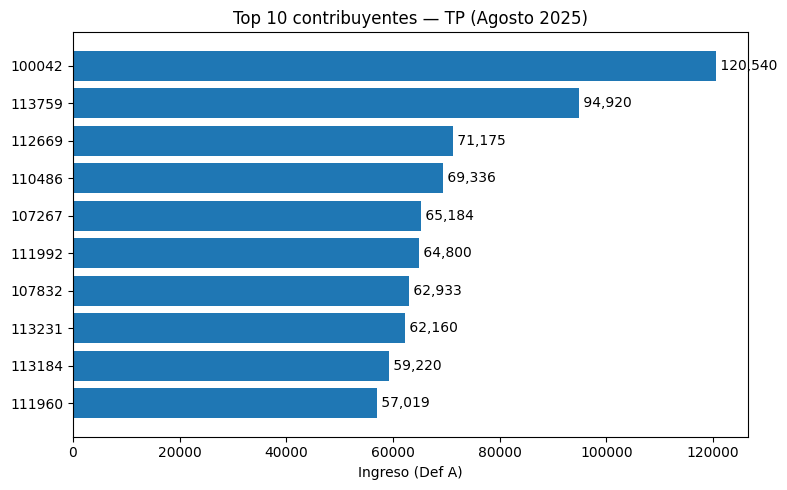

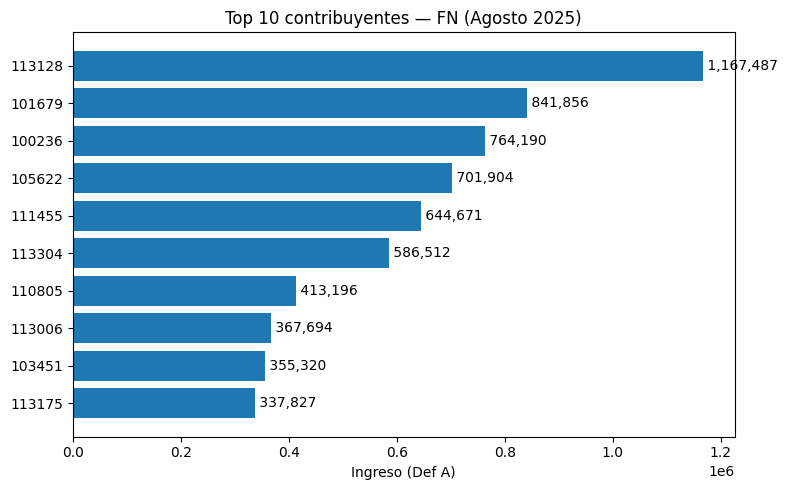

In [67]:
import matplotlib.pyplot as plt

# Si tenés Xy de agosto, mapeamos store_id a los índices para rotular
sid = None
if "Xy" in globals():
    xy_aug = Xy[Xy["period_month"].astype(str).str[:7].eq("2025-08")]
    sid = xy_aug["store_id"]

def top_plot(label, k=10):
    g = dfA.loc[dfA["caseU"].eq(label), ["ingreso_row_A"]].copy()
    g["store_id"] = sid.reindex(g.index) if sid is not None else g.index.astype(str)
    g = g.sort_values("ingreso_row_A", ascending=False).head(k)
    plt.figure(figsize=(8,5))
    plt.barh(g["store_id"].astype(str), g["ingreso_row_A"])
    plt.gca().invert_yaxis()
    plt.xlabel("Ingreso (Def A)")
    plt.title(f"Top {k} contribuyentes — {label} (Agosto 2025)")
    for i, v in enumerate(g["ingreso_row_A"].values):
        plt.text(v, i, f" {v:,.0f}", va="center")
    plt.tight_layout()
    plt.savefig(f"A_top{k}_{label}_hbar.png", dpi=200)
    plt.show()

top_plot("TP", k=10)
top_plot("FN", k=10)



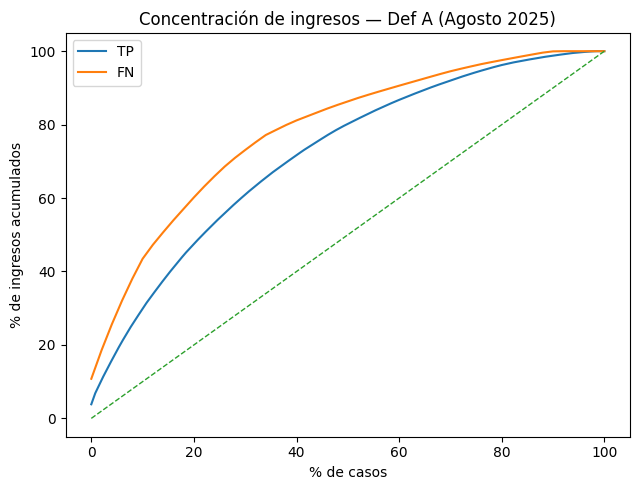

In [68]:
import numpy as np
import matplotlib.pyplot as plt

def cum_curve(vals):
    x = np.sort(vals)[::-1]
    x = x[x>=0]
    if len(x)==0: 
        return np.array([0.0]), np.array([0.0])
    w = x / (x.sum() if x.sum()>0 else 1.0)
    cum = np.cumsum(w)
    pct_cases = np.linspace(0, 100, len(cum), endpoint=True)
    pct_income = cum * 100
    return pct_cases, pct_income

tp_vals = dfA.loc[dfA["caseU"].eq("TP"), "ingreso_row_A"].values
fn_vals = dfA.loc[dfA["caseU"].eq("FN"), "ingreso_row_A"].values

tp_x, tp_y = cum_curve(tp_vals)
fn_x, fn_y = cum_curve(fn_vals)

plt.figure(figsize=(6.5,5))
plt.plot(tp_x, tp_y, label="TP")
plt.plot(fn_x, fn_y, label="FN")
plt.plot([0,100],[0,100], linestyle="--", linewidth=1)  # línea de igualdad
plt.xlabel("% de casos")
plt.ylabel("% de ingresos acumulados")
plt.title("Concentración de ingresos — Def A (Agosto 2025)")
plt.legend()
plt.tight_layout()
plt.savefig("A_curva_concentracion.png", dpi=200)
plt.show()



In [69]:
import pandas as pd
import numpy as np

def p50(x): 
    x = pd.to_numeric(x, errors="coerce")
    return float(np.nanmedian(x)) if len(x)>0 else np.nan

resA = pd.DataFrame({
    "casos": [
        int(dfA["caseU"].eq("TP").sum()),
        int(dfA["caseU"].eq("FN").sum())
    ],
    "KPI_total_DefA": [kpi_A_TP, kpi_A_FN],
    "ingreso_mediana": [
        p50(dfA.loc[dfA["caseU"].eq("TP"), "ingreso_row_A"]),
        p50(dfA.loc[dfA["caseU"].eq("FN"), "ingreso_row_A"])
    ],
    "gmv_lag1_mediana": [
        p50(dfA.loc[dfA["caseU"].eq("TP"), "gmv_lag1"]),
        p50(dfA.loc[dfA["caseU"].eq("FN"), "gmv_lag1"])
    ],
    "markdown_lag1_promedio": [
        float(dfA.loc[dfA["caseU"].eq("TP"), "markdown_mean_lag1"].mean()),
        float(dfA.loc[dfA["caseU"].eq("FN"), "markdown_mean_lag1"].mean())
    ],
    "comision_promedio": [
        float(dfA.loc[dfA["caseU"].eq("TP"), COMM_COL].mean()),
        float(dfA.loc[dfA["caseU"].eq("FN"), COMM_COL].mean())
    ],
}, index=["TP","FN"])

# Mostrar y exportar CSV (opcional)
display(resA.style.format({"KPI_total_DefA": "{:,.2f}", "ingreso_mediana": "{:,.2f}", "gmv_lag1_mediana": "{:,.0f}",
                           "markdown_lag1_promedio": "{:.2%}", "comision_promedio": "{:.2%}"}))
# resA.to_csv("A_resumen_tabla.csv")


,casos,KPI_total_DefA,ingreso_mediana,gmv_lag1_mediana,markdown_lag1_promedio,comision_promedio
TP,131,"3,143,247.68","17,136.84","50,728",3.28%,39.58%
FN,51,"10,829,630.84","102,451.54","374,950",6.56%,35.18%


In [42]:
import pandas as pd

# chequeos
if "case" not in df_mes.columns:
    raise KeyError("df_mes no tiene 'case'.")

case_upper = df_mes["case"].astype(str).str.upper()
tp_idx = df_mes.index[case_upper.eq("TP")]
fn_idx = df_mes.index[case_upper.eq("FN")]

print(f"df_mes shape: {df_mes.shape}")
print(f"TP: {len(tp_idx)} | FN: {len(fn_idx)} | FP: {(case_upper=='FP').sum()} | TN: {(case_upper=='TN').sum()}")

# muestro algunas filas para corroborar alineación visual si querés
display(df_mes.loc[tp_idx[:5], ["segmento","barrio","category","gmv_lag1","markdown_mean_lag1","y_true","y_pred","proba","case"]])
display(df_mes.loc[fn_idx[:5], ["segmento","barrio","category","gmv_lag1","markdown_mean_lag1","y_true","y_pred","proba","case"]])


df_mes shape: (3751, 24)
TP: 131 | FN: 51 | FP: 288 | TN: 3281


,segmento,barrio,category,gmv_lag1,markdown_mean_lag1,y_true,y_pred,proba,case
180,Microstores,recoleta,Sushi,286999.94,0.0,1,1,0.614059,TP
698,Microstores,nunez,NaN,32788.00,0.0,1,1,0.736281,TP
745,Microstores,balvanera,NaN,14600.00,0.0,1,1,0.761374,TP
1034,Picked Locals,balvanera,Helado,82000.00,0.0,1,1,0.666952,TP
1958,Microstores,san nicolas,Hamburguesa,82000.00,0.0,1,1,0.748136,TP


,segmento,barrio,category,gmv_lag1,markdown_mean_lag1,y_true,y_pred,proba,case
596,Microstores,flores,Argentina,298500.0,0.000000,1,0,0.373511,FN
651,Top Players,villa urquiza,Empanadas,1250988.0,0.104983,1,0,0.081215,FN
1243,Picked Locals,recoleta,Internacional,2547300.0,-0.000263,1,0,0.113548,FN
2154,Microstores,villa del parque,Desayunos y meriendas,659400.0,0.000000,1,0,0.105732,FN
4863,Microstores,chacarita,Arepas,336667.0,0.219715,1,0,0.288765,FN


In [43]:
import pandas as pd
import numpy as np

# 1) Validaciones mínimas en df_mes
need_cols = ["case", "gmv_lag1", "markdown_mean_lag1"]
missing = [c for c in need_cols if c not in df_mes.columns]
if missing:
    raise KeyError(f"Faltan columnas en df_mes: {missing}")

case_upper = df_mes["case"].astype(str).str.upper()
tp = df_mes.loc[case_upper.eq("TP")].copy()
fn = df_mes.loc[case_upper.eq("FN")].copy()

# 2) Normalizar tipos / rangos
for df_ in (tp, fn):
    df_["gmv_lag1"] = pd.to_numeric(df_["gmv_lag1"], errors="coerce").fillna(0)
    df_["markdown_mean_lag1"] = pd.to_numeric(df_["markdown_mean_lag1"], errors="coerce")
    # si viniera 0–100, pasamos a 0–1
    if df_["markdown_mean_lag1"].dropna().gt(1).any():
        df_["markdown_mean_lag1"] /= 100.0
    df_["markdown_mean_lag1"] = df_["markdown_mean_lag1"].clip(0,1).fillna(0)

# 3) Detectar columna de comisión dentro de df_mes
COM_CANDS = ["comision_actual","commission_rate","take_rate","commission","comision","comision_lag1","take_rate_lag1","commission_rate_lag1"]
com_col = next((c for c in COM_CANDS if c in df_mes.columns), None)

if com_col is not None:
    # preparar comisión en TP / FN
    for df_ in (tp, fn):
        df_[com_col] = pd.to_numeric(df_[com_col], errors="coerce")
        if df_[com_col].dropna().gt(1).any():
            df_[com_col] /= 100.0
        df_[com_col] = df_[com_col].clip(0,1).fillna(0)

    # 4A) KPI FINAL (con comisión) usando las columnas disponibles en df_mes (lag1)
    tp_ingresos = float((tp["gmv_lag1"] * (1 - tp["markdown_mean_lag1"]) * tp[com_col]).sum())
    fn_ingresos = float((fn["gmv_lag1"] * (1 - fn["markdown_mean_lag1"]) * fn[com_col]).sum())

    print(f"[df_mes] Columna de comisión detectada: '{com_col}' (se usó lag1)")
    print(f"Ingresos totales TP (agosto-2025, usando lag1): {tp_ingresos:,.2f}")
    print(f"Ingresos totales FN (agosto-2025, usando lag1): {fn_ingresos:,.2f}")

else:
    # 4B) PROXY (sin comisión) + aviso claro
    tp_proxy = float((tp["gmv_lag1"] * (1 - tp["markdown_mean_lag1"])).sum())
    fn_proxy = float((fn["gmv_lag1"] * (1 - fn["markdown_mean_lag1"])).sum())

    print("⚠️  df_mes NO tiene columna de comisión (p. ej., comision_actual/commission_rate/take_rate).")
    print("    Para el KPI FINAL hay que unir con la base del mes correspondiente.")
    print(f"    Mientras tanto, te dejo un PROXY sin comisión (GMV * (1 - markdown)) usando lag1:\n")
    print(f"Proxy ingresos TP (sin comisión, lag1): {tp_proxy:,.2f}")
    print(f"Proxy ingresos FN (sin comisión, lag1): {fn_proxy:,.2f}")


⚠️  df_mes NO tiene columna de comisión (p. ej., comision_actual/commission_rate/take_rate).
    Para el KPI FINAL hay que unir con la base del mes correspondiente.
    Mientras tanto, te dejo un PROXY sin comisión (GMV * (1 - markdown)) usando lag1:

Proxy ingresos TP (sin comisión, lag1): 7,989,728.11
Proxy ingresos FN (sin comisión, lag1): 40,257,040.13


In [26]:
def plot_discrete_counts(tp_df, fp_df, col, save=False):

    c_tp = tp_df[col].value_counts(dropna=False).sort_index()
    c_fp = fp_df[col].value_counts(dropna=False).sort_index()
    idx = c_tp.index.union(c_fp.index)

    c_tp = c_tp.reindex(idx, fill_value=0)
    c_fp = c_fp.reindex(idx, fill_value=0)

    x = np.arange(len(idx))
    w = 0.38
    plt.figure(figsize=(9, 4.5))
    plt.bar(x - w/2, c_tp.values, width=w, label="TP")
    plt.bar(x + w/2, c_fp.values, width=w, label="FP")
    plt.xticks(x, [str(i) for i in idx])
    plt.xlabel(col)
    plt.ylabel("conteo")
    plt.title(f"Distribución discreta – {col} (TP vs FP)")
    plt.legend()
    plt.tight_layout()
    if save:
        plt.savefig(f"disc_{col}_TP_vs_FP.png", dpi=200)
    plt.show()

# Llamado:
if "churn_streak_lag1" in df_mes.columns:
    plot_discrete_counts(tp, fp, "churn_streak_lag1", save=True)


TEST filas válidas: 3751  | TP=131  FP=288
Top-10 features por |SHAP| medio: ['tpn_lag1', 'days_with_orders_lag1', 'gmv_lag1', 'barrio', 'segmento', 'tpn_delta_1m', 'category', 'avg_shipping_cost_lag1', 'markdown_mean_lag1', 'gmv_roll3_std']


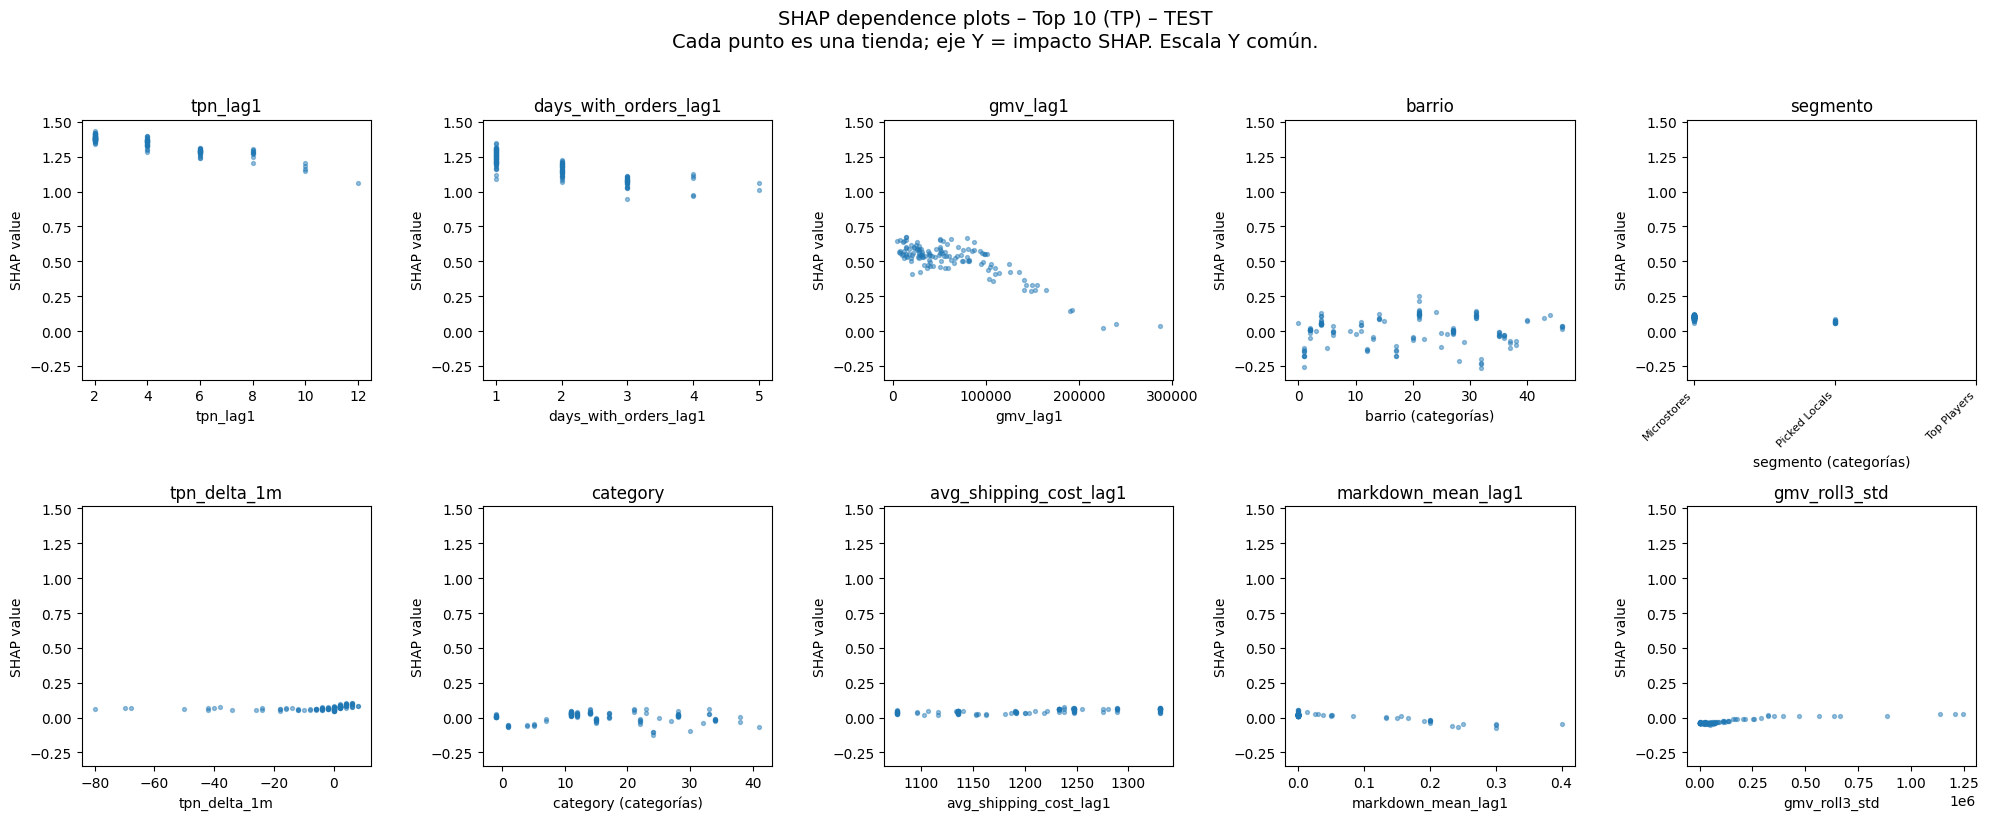

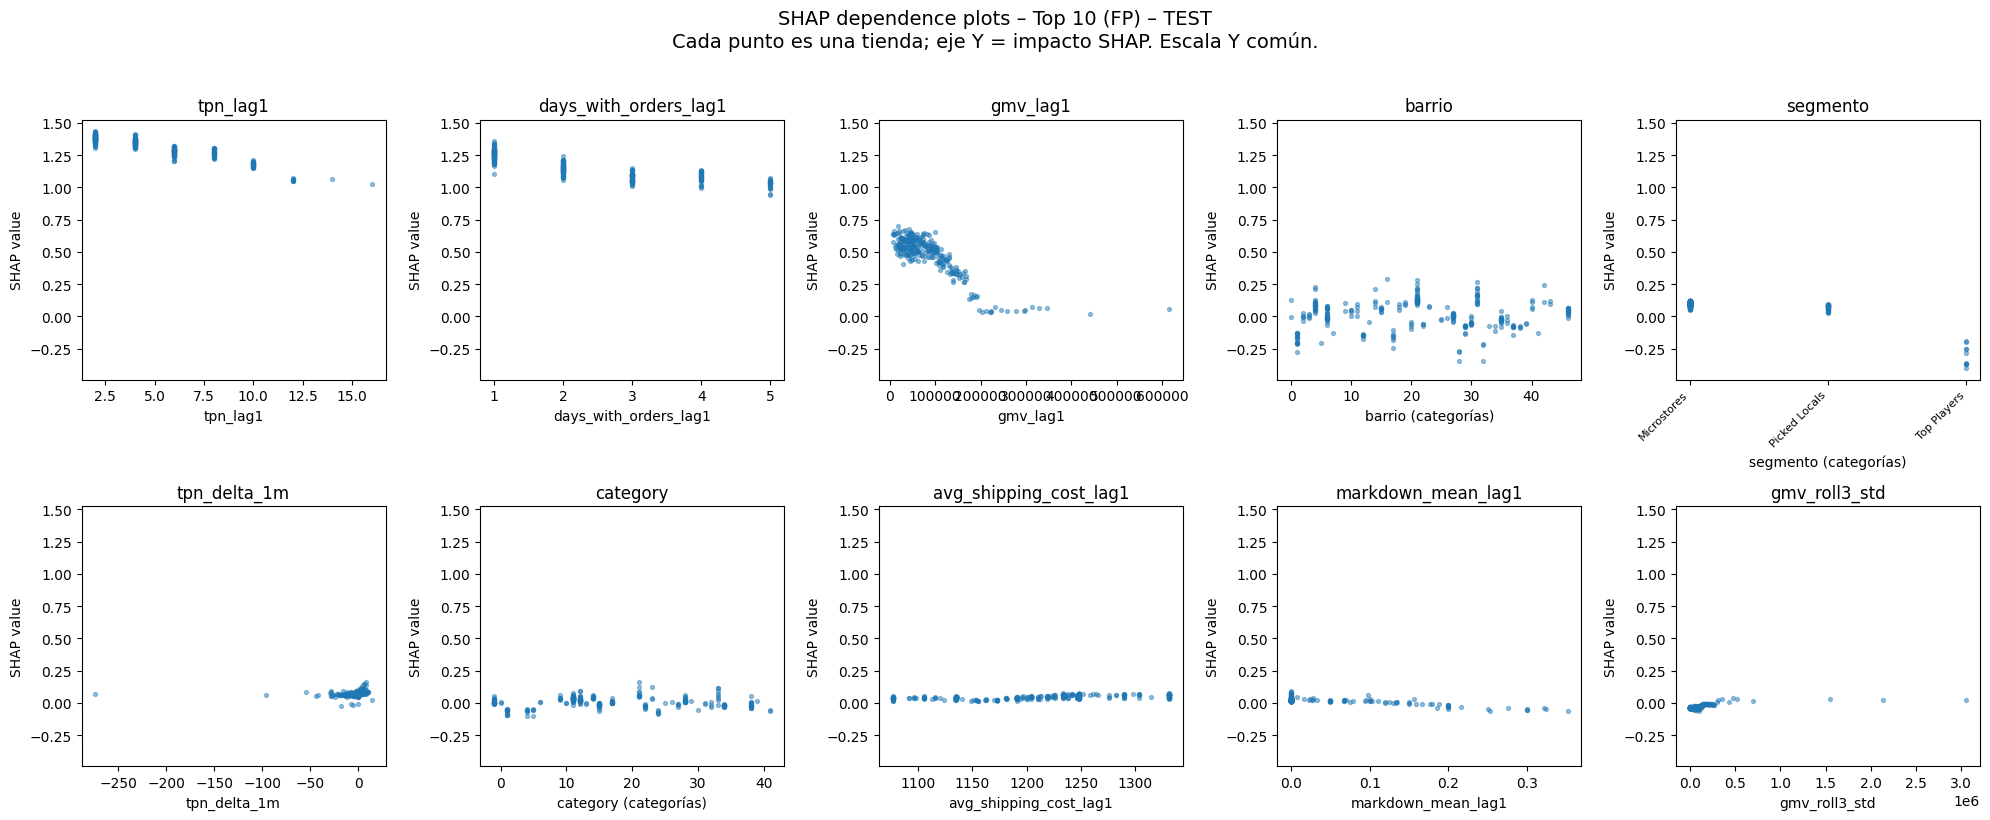

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# ========= Parámetros =========
SPLIT = "TEST"            # "TEST" o "VALID"
THR = 0.5946              # umbral que estás usando para clasificar

cat_cols = ("segmento","barrio","category")

# 1) Máscaras y probabilidades ya calculadas en run_pruned
if SPLIT.upper() == "TEST":
    mask = test_mask
    proba_series = pd.Series(run_pruned["test_prob"], index=Xy.index[test_mask])
else:
    mask = valid_mask
    proba_series = pd.Series(run_pruned["valid_prob"], index=Xy.index[valid_mask])

# 2) Tomar EXACTAMENTE las features usadas en entrenamiento (evita shape mismatch)
features_used = run_pruned.get("features_used", features_pruned)
X = Xy.loc[mask, features_used].copy()

# dtypes categóricos como en train
for c in cat_cols:
    if c in X.columns:
        X[c] = X[c].astype("category")

# 3) Etiquetas reales y predichas (para identificar TP/FP)
y_true = pd.to_numeric(Xy.loc[mask, "churn_unique"], errors="coerce")
valid_rows = y_true.notna()
y_true = y_true[valid_rows].astype(int)

# alineo X y probabilidades a las filas válidas
X = X.loc[valid_rows].copy()
scores = proba_series.loc[X.index]
y_pred = (scores >= THR).astype(int)

# Máscaras TP/FP
mask_tp = (y_true == 1) & (y_pred == 1)
mask_fp = (y_true == 0) & (y_pred == 1)

print(f"{SPLIT} filas válidas: {len(X)}  | TP={mask_tp.sum()}  FP={mask_fp.sum()}")

# 4) Calcular SHAP values con las mismas features (pred_contrib=True quita problemas)
model = run_pruned.get("model", run_pruned.get("booster", None))
if model is None:
    raise ValueError("run_pruned no contiene 'model' ni 'booster'.")

shap_vals_full = model.predict(X, pred_contrib=True)     # [n_samples, n_features+1]
expected_value = shap_vals_full[:, -1].mean()
shap_vals = shap_vals_full[:, :-1]                       # quitamos bias para plots

# 5) Top-10 por |SHAP| medio (sobre TODO el split, no por subgrupo)
mean_abs = np.abs(shap_vals).mean(axis=0)
order = np.argsort(mean_abs)[::-1]
top_idx = order[:10]
top_cols = X.columns[top_idx]
print("Top-10 features por |SHAP| medio:", list(top_cols))

# ---------- Helper para grilla de dependence plots ----------
def plot_shap_dependence_grid(X_sub, shap_sub, feature_indices, title, cat_cols=(), savepath=None):
    """
    X_sub: DataFrame (solo filas del subgrupo, ej. TP)
    shap_sub: ndarray (solo filas del subgrupo), columnas = features_used
    feature_indices: índices (en columnas de X_sub / shap_sub) de las top features
    """
    if X_sub.shape[0] == 0:
        print(f"[{title}] Sin filas para graficar.")
        return

    # mismo eje Y para todas las subplots (comparabilidad)
    y_min = shap_sub[:, feature_indices].min()
    y_max = shap_sub[:, feature_indices].max()
    pad = 0.05 * (y_max - y_min + 1e-9)
    y_min, y_max = y_min - pad, y_max + pad

    nrows, ncols = 2, 5
    plt.figure(figsize=(20, 8))
    for i, j in enumerate(feature_indices, start=1):
        col = X_sub.columns[j]
        y = shap_sub[:, j]
        x = X_sub[col]

        ax = plt.subplot(nrows, ncols, i)

        # Categóricas: graficar codes y opcionalmente labels si no son muchas
        if str(x.dtype) == "category" or col in cat_cols:
            x_codes = x.cat.codes
            ax.scatter(x_codes, y, s=8, alpha=0.45)
            # ticks si hay pocas categorías
            cats = list(x.cat.categories) if hasattr(x, "cat") else sorted(x.unique())
            if len(cats) <= 12:
                ticks = np.arange(len(cats))
                ax.set_xticks(ticks)
                ax.set_xticklabels([str(c) for c in cats], rotation=45, ha="right", fontsize=8)
            ax.set_xlabel(f"{col} (categorías)")
        else:
            ax.scatter(x.values, y, s=8, alpha=0.45)
            ax.set_xlabel(col)

        ax.set_title(col)
        ax.set_ylabel("SHAP value")
        ax.set_ylim([y_min, y_max])

    plt.suptitle(title + "\nCada punto es una tienda; eje Y = impacto SHAP. Escala Y común.", y=1.02, fontsize=14)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()

# 6) Grillas separadas para TP y FP
# Subsets de filas y SHAP
X_tp  = X.loc[mask_tp]
X_fp  = X.loc[mask_fp]
SV_tp = shap_vals[mask_tp.values, :]
SV_fp = shap_vals[mask_fp.values, :]

plot_shap_dependence_grid(
    X_sub=X_tp,
    shap_sub=SV_tp,
    feature_indices=top_idx,
    title=f"SHAP dependence plots – Top 10 (TP) – {SPLIT}",
    cat_cols=cat_cols,
    savepath=f"shap_dependence_top10_{SPLIT}_TP.png"
)

plot_shap_dependence_grid(
    X_sub=X_fp,
    shap_sub=SV_fp,
    feature_indices=top_idx,
    title=f"SHAP dependence plots – Top 10 (FP) – {SPLIT}",
    cat_cols=cat_cols,
    savepath=f"shap_dependence_top10_{SPLIT}_FP.png"
)


### Prueba dejando solo las core features

Training until validation scores don't improve for 200 rounds


[100]	train's auc: 0.961916	train's average_precision: 0.537777	valid's auc: 0.925659	valid's average_precision: 0.389867
[200]	train's auc: 0.980455	train's average_precision: 0.676473	valid's auc: 0.924039	valid's average_precision: 0.382776
Early stopping, best iteration is:
[27]	train's auc: 0.93303	train's average_precision: 0.368675	valid's auc: 0.92663	valid's average_precision: 0.385261


,0
threshold,0.546600
TP,142.000000
FP,311.000000
TN,2988.000000
FN,41.000000
precision,0.313466
recall,0.775956
specificity,0.905729
f1,0.446541
balanced_accuracy,0.840843


,0
threshold,0.546600
TP,135.000000
FP,306.000000
TN,3263.000000
FN,47.000000
precision,0.306122
recall,0.741758
specificity,0.914262
f1,0.433387
balanced_accuracy,0.828010


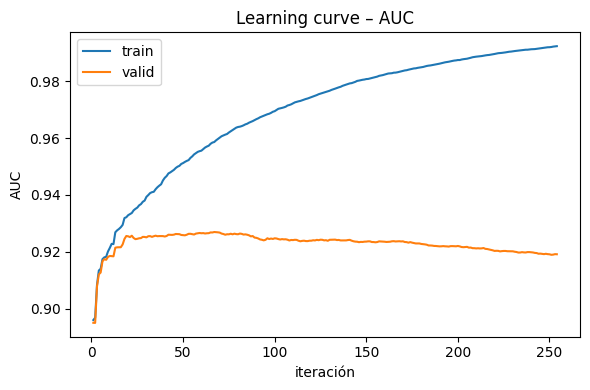

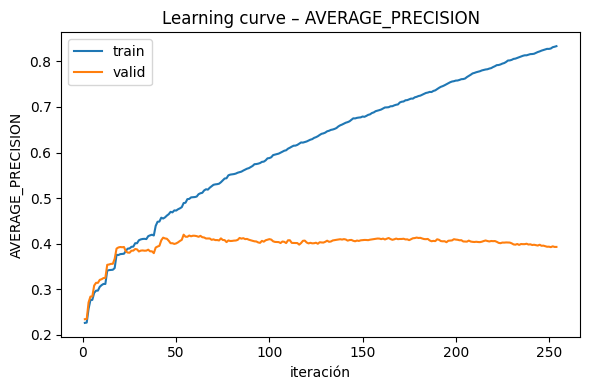

In [28]:
whitelist_core = [
    'days_with_orders_lag1','tpn_lag1','barrio','gmv_lag1','category',
    'tpn_delta_1m','segmento','avg_shipping_cost_lag1','gmv_lag2','markdown_mean_lag1',
    # opcionales:
    'tpn_pctchg_1m','open_rate_lag1'
]
features_core = [f for f in whitelist_core if f in Xy.columns]

run_core = train_and_predict_lgbm(
    Xy, train_mask, valid_mask, test_mask,
    target_col="churn_unique",
    cat_cols=("segmento","barrio","category"),
    features_to_use=features_core,
    output_mode="proba"
)

thr_f2_c, p_f2_c, r_f2_c, f2_c = pick_threshold_by_fbeta(run_core["y_valid"], run_core["valid_prob"], beta=2.0)
valid_metrics_c, valid_cm_c = evaluate_at_threshold(run_core["y_valid"], run_core["valid_prob"], thr_f2_c)
test_metrics_c,  test_cm_c  = evaluate_at_threshold(run_core["y_test"],  run_core["test_prob"],  thr_f2_c)
display(pd.DataFrame([valid_metrics_c]).T); display(pd.DataFrame([test_metrics_c]).T)

ev = run_tmp["evals_result"]

for metric in ["auc","average_precision"]:
    if "train" in ev and metric in ev["train"]:
        iters = range(1, len(ev["train"][metric]) + 1)
        plt.figure(figsize=(6,4))
        plt.plot(iters, ev["train"][metric], label="train")
        plt.plot(iters, ev["valid"][metric], label="valid")
        plt.xlabel("iteración")
        plt.ylabel(metric.upper())
        plt.title(f"Learning curve – {metric.upper()}")
        plt.legend()
        plt.tight_layout()
        plt.show()


,feature,gain,split,gain_norm
0,days_with_orders_lag1,57335.063777,63,0.723764
1,tpn_lag1,7707.495310,26,0.097295
3,gmv_lag1,4834.538970,33,0.061028
5,tpn_delta_1m,2350.541927,22,0.029672
4,category,1866.578259,28,0.023563
2,barrio,1851.563362,19,0.023373
6,segmento,1446.868999,16,0.018264
9,markdown_mean_lag1,701.291180,20,0.008853
8,gmv_lag2,645.608603,18,0.008150
7,avg_shipping_cost_lag1,318.869604,14,0.004025


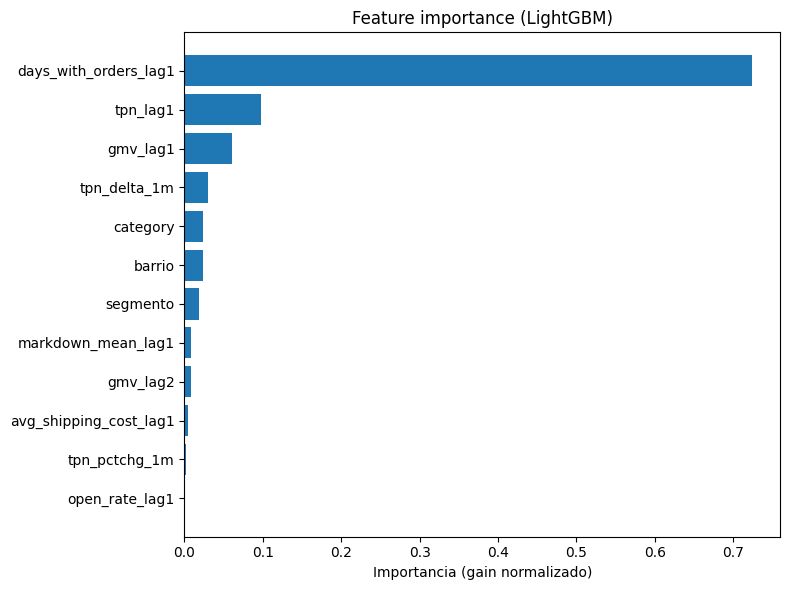

In [29]:
# construir el DF de importancia (usá tu lista 'features')
df_imp = feature_importance_df(run_core["model"], run_core["features"])
display(df_imp.head(30))  # top 30 por gain

# gráfico (top 20 por gain normalizado)
top = df_imp.head(20).iloc[::-1]  # invertimos para barh
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["gain_norm"])
plt.xlabel("Importancia (gain normalizado)")
plt.title("Feature importance (LightGBM)")
plt.tight_layout()
plt.show()

### Análisis streaks

In [30]:
# --- 1) Helper: construye df de evaluación con churn_streak (t) desde df_ctx --
def make_eval_df(Xy, mask, y_true, y_score, df_ctx_all, thr, label_month):
    # base con claves + target
    base = Xy.loc[mask, ['store_id','period_month','churn_unique']].copy()
    base = base.rename(columns={'churn_unique':'y'}).reset_index(drop=True)

    # anexar score y pred binaria
    base['score'] = np.asarray(y_score)
    base['yhat']  = (base['score'] >= thr).astype(int)

    # traer churn_streak del MES ACTUAL desde df_ctx
    ctx_cols = ['store_id','period_month','churn_streak']
    ctx = df_ctx_all[ctx_cols].copy()
    ctx['period_month'] = pd.to_datetime(ctx['period_month'])
    base['period_month'] = pd.to_datetime(base['period_month'])

    eval_df = base.merge(ctx, on=['store_id','period_month'], how='left')

    # banderas y clase
    eval_df['streak_flag'] = np.where(pd.to_numeric(eval_df['churn_streak'], errors='coerce').fillna(0) > 0,
                                      'Con streak (>0)', 'Sin streak (=0)')

    def classify(row):
        if row['y']==1 and row['yhat']==1: return 'TP'
        if row['y']==1 and row['yhat']==0: return 'FN'
        if row['y']==0 and row['yhat']==1: return 'FP'
        return 'TN'
    eval_df['clase'] = eval_df.apply(classify, axis=1)

    # (opcional) filtrar por el mes exacto (por seguridad)
    if isinstance(label_month, str):
        pmask = (eval_df['period_month'].dt.to_period('M') == pd.Period(label_month))
        eval_df = eval_df.loc[pmask].copy()

    return eval_df

# --- 2) Construir eval_df para VALID (julio) y TEST (agosto) ---
thr = thr_f2  # o el umbral que elijas

eval_valid = make_eval_df(Xy, valid_mask, y_valid, valid_pred, df_ctx_all, thr, '2025-07')
eval_test  = make_eval_df(Xy, test_mask,  y_test,  test_pred,  df_ctx_all, thr, '2025-08')

# --- 3) Tablas: por clase (TP/FN/FP/TN) × streak_flag ---
def streak_table(eval_df, title):
    cnt = (eval_df
           .groupby(['clase','streak_flag'])
           .size()
           .unstack(fill_value=0)
           .loc[['TP','FN','FP','TN']])  # orden fijo
    pct = (cnt.div(cnt.sum(axis=1), axis=0)*100).round(1)
    print(f"\n{title} — Conteos")
    display(cnt)
    print(f"{title} — Porcentajes dentro de cada clase")
    display(pct)
    return cnt, pct

cnt_valid, pct_valid = streak_table(eval_valid, "VALID (Jul 2025)")
cnt_test,  pct_test  = streak_table(eval_test,  "TEST  (Ago 2025)")



VALID (Jul 2025) — Conteos


streak_flag,Con streak (>0),Sin streak (=0)
clase,,
TP,147,0
FN,36,0
FP,0,337
TN,954,2008


VALID (Jul 2025) — Porcentajes dentro de cada clase


streak_flag,Con streak (>0),Sin streak (=0)
clase,,
TP,100.0,0.0
FN,100.0,0.0
FP,0.0,100.0
TN,32.2,67.8



TEST  (Ago 2025) — Conteos


streak_flag,Con streak (>0),Sin streak (=0)
clase,,
TP,139,0
FN,43,0
FP,0,347
TN,1080,3684


TEST  (Ago 2025) — Porcentajes dentro de cada clase


streak_flag,Con streak (>0),Sin streak (=0)
clase,,
TP,100.0,0.0
FN,100.0,0.0
FP,0.0,100.0
TN,22.7,77.3


In [31]:
# === Distribución de churn_streak por clase (TP/FN/FP/TN) ===
def distrib_streak_por_clase(eval_df, titulo="(t)"):
    clases = ["TP","FN","FP","TN"]
    out = {}
    for cls in clases:
        sub = eval_df.loc[eval_df['clase'] == cls, 'churn_streak']
        # tabla de frecuencia
        tab = (sub.value_counts(dropna=False)
                   .sort_index()
                   .to_frame('casos'))
        tab['pct'] = (tab['casos'] / tab['casos'].sum()).round(3)
        out[cls] = tab
        print(f"\n{cls} – distribución de churn_streak en t {titulo}")
        display(tab)

    # bucketizamos: 0 / 1 / >1
    def bucketize(x):
        x = pd.to_numeric(x, errors='coerce')
        if pd.isna(x): return "NaN"
        if x == 0:     return "0"
        if x == 1:     return "1"
        return ">1"

    dfb = eval_df[['clase','churn_streak']].copy()
    dfb['streak_bucket'] = dfb['churn_streak'].map(bucketize)
    pivot = (dfb
             .groupby(['clase','streak_bucket'])
             .size()
             .unstack(fill_value=0)
             .reindex(index=clases, fill_value=0))
    pivot_pct = (pivot.div(pivot.sum(axis=1), axis=0)*100).round(1)

    print("\nResumen por clase (conteos):")
    display(pivot)
    print("Resumen por clase (porcentajes %):")
    display(pivot_pct)

    return out, pivot, pivot_pct

# Usá eval_test (agosto) o eval_valid (julio)
distros, pivot_cnt, pivot_pct = distrib_streak_por_clase(eval_test, titulo="(agosto)")

# === Recall de ONSET puro (streak==1 en t) ===
tp1 = ((eval_test['clase']=="TP") & (eval_test['churn_streak']==1)).sum()
fn1 = ((eval_test['clase']=="FN") & (eval_test['churn_streak']==1)).sum()
recall_onset_puro = tp1 / (tp1 + fn1) if (tp1+fn1)>0 else float('nan')
print(f"\nRecall ONSET puro (streak==1 en agosto): {recall_onset_puro:.3f}")




TP – distribución de churn_streak en t (agosto)


,casos,pct
churn_streak,,
1.0,139,1.0



FN – distribución de churn_streak en t (agosto)


,casos,pct
churn_streak,,
1.0,43,1.0



FP – distribución de churn_streak en t (agosto)


...


Resumen por clase (conteos):


streak_bucket,0,1,>1,NaN
clase,,,,
TP,0,139,0,0
FN,0,43,0,0
FP,347,0,0,0
TN,2142,0,1080,1542


Resumen por clase (porcentajes %):


streak_bucket,0,1,>1,NaN
clase,,,,
TP,0.0,100.0,0.0,0.0
FN,0.0,100.0,0.0,0.0
FP,100.0,0.0,0.0,0.0
TN,45.0,0.0,22.7,32.4



Recall ONSET puro (streak==1 en agosto): 0.764


AGOSTO — Distribución de churn_unique


,casos,%
churn_unique,,
No churn (0),3569,95.1
Churn (1),182,4.9


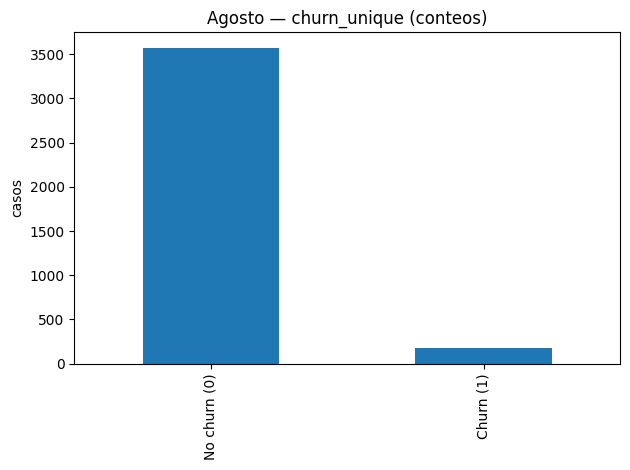

AGOSTO — Distribución de churn_streak (t)


,casos,%
churn_streak,,
0.0,2489,47.0
1.0,182,3.4
2.0,142,2.7
3.0,109,2.1
4.0,122,2.3
5.0,94,1.8
6.0,88,1.7
7.0,75,1.4
8.0,78,1.5


AGOSTO — churn_streak bucketizado (0/1/2/3+/NaN)


,casos,%
streak_bucket,,
0,2489,47.0
1,182,3.4
2,142,2.7
3+,938,17.7
NaN,1542,29.1


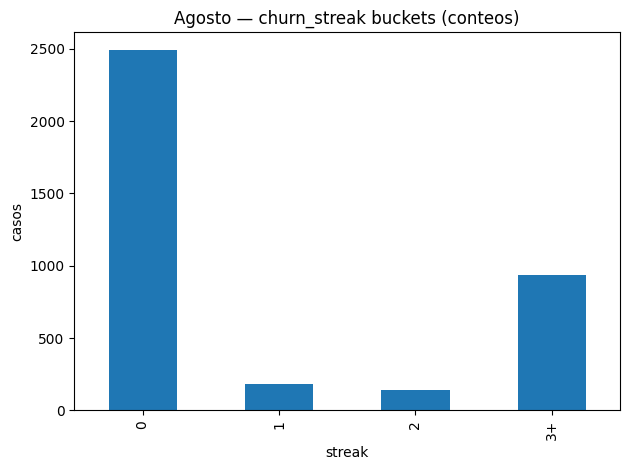

AGOSTO — Cruce churn_unique × streak_bucket (conteos)


streak_bucket,0,1,2,3+,NaN
churn_unique,,,,,
No churn (0),2489,0,142,938,0
Churn (1),0,182,0,0,0


AGOSTO — Cruce churn_unique × streak_bucket (%)


streak_bucket,0,1,2,3+,NaN
churn_unique,,,,,
No churn (0),69.7,0.0,4.0,26.3,0.0
Churn (1),0.0,100.0,0.0,0.0,0.0


In [32]:
# === Distribuciones en AGOSTO 2025 ===
# Usamos la base elegible
aug = df_ctx_all.loc[df_ctx_all['period_month'].dt.to_period('M') == pd.Period('2025-08')].copy()

# Asegurar tipos
aug['churn_unique'] = pd.to_numeric(aug['churn_unique'], errors='coerce')
aug['churn_streak'] = pd.to_numeric(aug['churn_streak'], errors='coerce')

# ----- 1) churn_unique (0/1) -----
cu_cnt = aug.loc[aug['churn_unique'].notna(), 'churn_unique'].value_counts().rename({0:'No churn (0)',1:'Churn (1)'}).to_frame('casos')
cu_pct = (cu_cnt / cu_cnt.sum() * 100).round(1).rename(columns={'casos':'%'})
print("AGOSTO — Distribución de churn_unique")
display(cu_cnt.join(cu_pct))

# (opcional) gráfico
cu_plot = cu_cnt.copy()
cu_plot.plot(kind='bar', legend=False, title='Agosto — churn_unique (conteos)')
plt.ylabel('casos'); plt.xlabel(''); plt.tight_layout(); plt.show()

# ----- 2) churn_streak (conteos y %; ordenado) -----
cs_cnt = aug['churn_streak'].value_counts(dropna=False).sort_index().to_frame('casos')
cs_pct = (cs_cnt / cs_cnt.sum() * 100).round(1).rename(columns={'casos':'%'})
print("AGOSTO — Distribución de churn_streak (t)")
display(cs_cnt.join(cs_pct))

# (opcional) bucketizar 0 / 1 / 2 / 3+
def _bucket_streak(x):
    x = pd.to_numeric(x, errors='coerce')
    if pd.isna(x): return 'NaN'
    if x == 0: return '0'
    if x == 1: return '1'
    if x == 2: return '2'
    return '3+'

aug['streak_bucket'] = aug['churn_streak'].map(_bucket_streak)
sb_cnt = aug['streak_bucket'].value_counts().reindex(['0','1','2','3+','NaN']).fillna(0).astype(int).to_frame('casos')
sb_pct = (sb_cnt / sb_cnt.sum() * 100).round(1).rename(columns={'casos':'%'})
print("AGOSTO — churn_streak bucketizado (0/1/2/3+/NaN)")
display(sb_cnt.join(sb_pct))

# (opcional) gráfico buckets
sb_cnt.loc[['0','1','2','3+']].plot(kind='bar', legend=False, title='Agosto — churn_streak buckets (conteos)')
plt.ylabel('casos'); plt.xlabel('streak'); plt.tight_layout(); plt.show()

# ----- 3) Cruce churn_unique × streak_bucket -----
ct = (aug.loc[aug['churn_unique'].notna()]
        .pivot_table(index='churn_unique', columns='streak_bucket', values='store_id', aggfunc='count', fill_value=0)
        .rename(index={0:'No churn (0)',1:'Churn (1)'})
        .reindex(columns=['0','1','2','3+','NaN'], fill_value=0))
ct_pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(1)

print("AGOSTO — Cruce churn_unique × streak_bucket (conteos)")
display(ct)
print("AGOSTO — Cruce churn_unique × streak_bucket (%)")
display(ct_pct)


### Prueba con data real de septiembre

In [33]:
data_sep_real = pd.read_csv('/Users/danna/Desktop/ITBA/2025 2C/Proyecto-Final/churn-bite/data_real_septiembre_full.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/Users/danna/Desktop/ITBA/2025 2C/Proyecto-Final/churn-bite/data_real_septiembre_full.csv'

In [ ]:
df_sep = data_sep_real.copy()

# Tipos y columnas
df_sep['created_date'] = pd.to_datetime(df_sep['created_date'], errors='coerce')
df_sep = df_sep.rename(columns={'store_id_anon':'store_id'})

# Target “real” de septiembre: churn_unique = 1 si TPN == 0; 0 si TPN > 0
df_sep['churn_real_any'] = (pd.to_numeric(df_sep['TPN'], errors='coerce').fillna(0) == 0).astype(int)
# nota: 'churn_unique_real' la vamos a construir después usando TPN de agosto

# Alinear tipo de store_id con Xy (por si uno es float)
try:
    df_sep['store_id'] = df_sep['store_id'].astype(int)
except Exception:
    pass
sep_ids = set(df_sep['store_id'].dropna().astype(int))

In [ ]:
# Fechas (meses completos)
train_mask = Xy['period_month'].between('2025-04-01','2025-07-31') & Xy['churn_unique'].notna()
valid_mask = Xy['period_month'].between('2025-08-01','2025-08-31') & Xy['churn_unique'].notna()
pred_mask  = (Xy['period_month'].between('2025-08-01','2025-08-31')) & (Xy['store_id'].isin(sep_ids))

run_sep = train_and_predict_lgbm(
    Xy, train_mask, valid_mask, pred_mask,   # test_mask = septiembre
    target_col="churn_unique",
    cat_cols=("segmento","barrio","category"),
    features_to_use=None,        # o tu lista de features si querés restringir
    output_mode="binary",        # ← devuelve proba + binario
    threshold_strategy="f2",     # ← umbral elegido por F2 en AGO (valid)
    beta=2.0
)

# Tomamos lo que vamos a usar
thr_sep     = run_sep["threshold"]      # umbral F2 elegido en AGO
y_valid_aug = run_sep["y_valid"]        # target de AGO (para control)
prob_aug    = run_sep["valid_prob"]     # proba en AGO (para control)
prob_sep    = run_sep["test_prob"]      # proba en SEP (lo que nos interesa)
yhat_sep    = run_sep["test_pred_bin"]  # binario en SEP con thr_sep


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.988053	train's average_precision: 0.766894	valid's auc: 0.931353	valid's average_precision: 0.393237
[200]	train's auc: 0.9986	train's average_precision: 0.961287	valid's auc: 0.929628	valid's average_precision: 0.379104
Early stopping, best iteration is:
[25]	train's auc: 0.955366	train's average_precision: 0.426966	valid's auc: 0.933168	valid's average_precision: 0.362171


# Evaluar performance (hasta acá funciona ok la parte de sep. de acá en adelante rompe)

In [ ]:
# Extraer claves del set de septiembre desde Xy
keys_sep = Xy.loc[pred_mask, ['store_id']].reset_index(drop=True)

# TPN de AGOSTO desde tu base modelada (para detectar ONSET en septiembre)
aug = df_ctx_all[df_ctx_all['period_month'].dt.to_period('M') == pd.Period('2025-08')][['store_id','tpn']].copy()
aug = aug.rename(columns={'tpn':'TPN_aug'})


pred_sep_df = keys_sep.assign(
    score = prob_sep,
    yhat  = yhat_sep
)

# Marcar mes de predicción = septiembre 2025
pred_sep_df['period_month'] = pd.Timestamp('2025-09-01')

pred_sep_df = pred_sep_df.drop_duplicates(subset='store_id')
df_sep_u = df_sep.drop_duplicates(subset='store_id', keep='last')[['store_id','churn_real_any']]

# Usar df_sep_u deduplicado por store_id (ya lo habías agregado)
# OJO: ahora 'churn_real_any' viene de df_sep
eval_sep = (pred_sep_df
            .merge(df_sep_u.rename(columns={'churn_unique_real':'churn_real_any'}), on='store_id', how='left')
            .merge(aug, on='store_id', how='left'))

# ONSET real de septiembre: sin ventas en sep (churn_real_any==1) Y sí había ventas en agosto
eval_sep['churn_unique_real'] = (
    (eval_sep['churn_real_any'] == 1) &
    (pd.to_numeric(eval_sep['TPN_aug'], errors='coerce').fillna(0) > 0)
).astype(int)


# Chequeo de cobertura
n_pred  = len(pred_sep_df)
n_match = eval_sep['churn_unique_real'].notna().sum()
print(f"Predicciones SEP: {n_pred} | Matcheadas contra data_sep_real: {n_match}")


KeyError: "['churn_unique_real'] not in index"

In [ ]:
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    balanced_accuracy_score, roc_auc_score, average_precision_score
)
import numpy as np

# Filas con target real disponible
m = eval_sep['churn_unique_real'].notna()
y_true_sep = eval_sep.loc[m, 'churn_unique_real'].astype(int).values
p_sep      = eval_sep.loc[m, 'score'].values
yhat_bin   = eval_sep.loc[m, 'yhat'].astype(int).values

cm = confusion_matrix(y_true_sep, yhat_bin, labels=[0,1])
tn, fp, fn, tp = cm.ravel()

metrics_sep = {
    "threshold": float(thr_sep),
    "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
    "precision": precision_score(y_true_sep, yhat_bin, zero_division=0),
    "recall":    recall_score(y_true_sep, yhat_bin, zero_division=0),
    "f1":        f1_score(y_true_sep, yhat_bin, zero_division=0),
    "balanced_accuracy": balanced_accuracy_score(y_true_sep, yhat_bin),
    "AUC":   roc_auc_score(y_true_sep, p_sep),
    "AUPRC": average_precision_score(y_true_sep, p_sep),
    "base_rate": float(np.mean(y_true_sep))
}
print("— SEP 2025 —")
for k,v in metrics_sep.items():
    print(f"{k:>18}: {v}")


— SEP 2025 —
         threshold: 0.46793699497572594
                TP: 0
                FP: 195
                TN: 1910
                FN: 0
         precision: 0.0
            recall: 0.0
                f1: 0.0
 balanced_accuracy: 0.9073634204275535
               AUC: nan
             AUPRC: 0.0
         base_rate: 0.0


/Users/danna/miniconda3/envs/eda_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/danna/miniconda3/envs/eda_env/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/danna/miniconda3/envs/eda_env/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


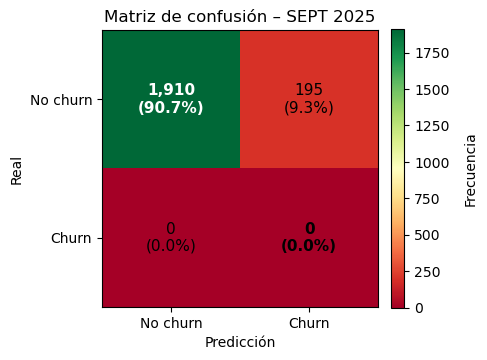

In [ ]:
plot_confusion(cm, title="Matriz de confusión – SEPT 2025", percent=True)

In [ ]:
(df_sep['TPN'].fillna(0).astype(float) == 0).sum()

np.int64(10055)

In [ ]:
(df_sep['TPN'].fillna(0).astype(float) != 0).sum()


np.int64(96067)

# LightGBM probabilístico

In [ ]:
# ENTRENAR → devuelve PROBABILIDADES (no binariza)
run_proba = train_and_predict_lgbm(
    Xy, train_mask, valid_mask, test_mask,
    target_col="churn_unique",
    cat_cols=("segmento","barrio","category"),
    features_to_use=None,     # o tu lista específica de features
    output_mode="proba"       # <<--- clave: modo probabilístico
)

# Tomo targets y probabilidades
y_valid    = run_proba["y_valid"]
y_test     = run_proba["y_test"]
valid_prob = run_proba["valid_prob"]
test_prob  = run_proba["test_prob"]


Training until validation scores don't improve for 200 rounds
[100]	train's auc: 0.991788	train's average_precision: 0.817587	valid's auc: 0.923075	valid's average_precision: 0.3963
[200]	train's auc: 0.999417	train's average_precision: 0.982662	valid's auc: 0.919972	valid's average_precision: 0.392673
Early stopping, best iteration is:
[48]	train's auc: 0.970733	train's average_precision: 0.553517	valid's auc: 0.924678	valid's average_precision: 0.400752


In [ ]:
thr_f2, p_f2, r_f2, f2 = pick_threshold_by_fbeta(y_valid, valid_prob, beta=2.0)
print(f"Umbral F2 (VALID): {thr_f2:.4f} | P={p_f2:.3f} R={r_f2:.3f} F2={f2:.3f}")

Umbral F2 (VALID): 0.5421 | P=0.326 R=0.760 F2=0.600


In [ ]:
def prob_dist_plot(y_true, y_prob, thr=None, title="Distribución de probabilidades"):
    y = pd.Series(y_true).reset_index(drop=True).astype(int)
    p = np.asarray(y_prob)
    bins = np.linspace(0, 1, 26)

    plt.figure(figsize=(7,4))
    plt.hist(p[y==0], bins=bins, alpha=0.7, label="Clase 0 (no onset)")
    plt.hist(p[y==1], bins=bins, alpha=0.7, label="Clase 1 (onset)")
    if thr is not None:
        plt.axvline(thr, linestyle="--")
    ap  = average_precision_score(y, p)
    auc = roc_auc_score(y, p)
    plt.title(f"{title}  |  AP={ap:.3f}  AUC={auc:.3f}")
    plt.xlabel("Probabilidad predicha")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.tight_layout()
    plt.show()

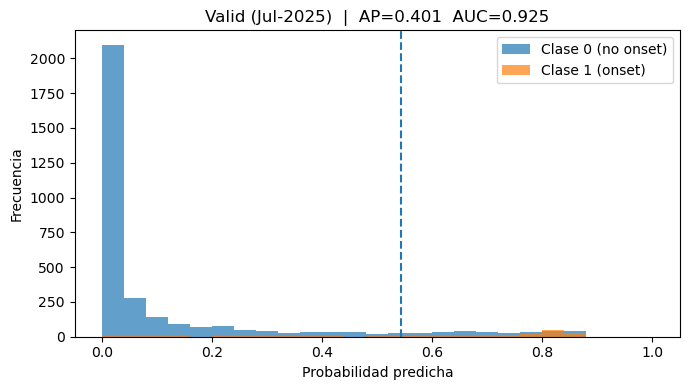

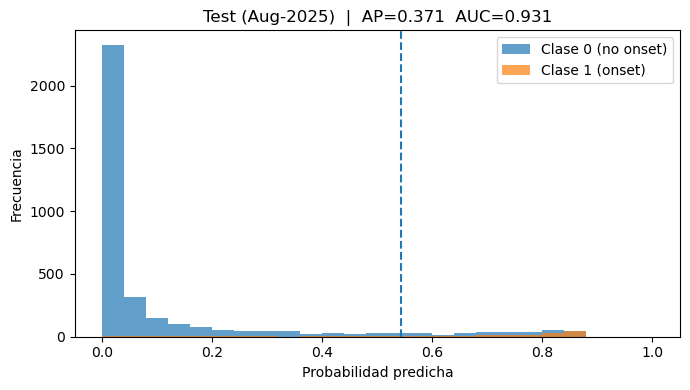

In [ ]:
# Con línea en el umbral F2 (opcional). Si no querés línea: pasá thr=None.
prob_dist_plot(y_valid, valid_prob, thr=thr_f2, title="Valid (Jul-2025)")
prob_dist_plot(y_test,  test_prob,  thr=thr_f2, title="Test (Aug-2025)")